# Setup

In [30]:
# Standard library imports
import warnings

# Third-party imports: core data -> modeling -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.mlemodel import MLEModel
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# Configuration & settings
warnings.simplefilter(action="ignore")        # silence optimizer/frequency chatter

The script initializes an environment tailored for time series analysis and statistical modeling. By using `warnings.simplefilter(action="ignore")`, it suppresses all warning messages, which prevents output clutter caused by optimizer convergence issues or frequency mismatches during model execution.

Data manipulation is managed through `numpy` for numerical arrays and `pandas` for structured dataframes. The `matplotlib.pyplot` library is included to facilitate the visualization of data and statistical results.

The core analytical capabilities come from the `statsmodels` library. Specifically, it imports `adfuller` to perform the Augmented Dickey-Fuller test for checking stationarity in time series data. It also includes `MLEModel` for working with Maximum Likelihood Estimation in state-space models and `ETSModel` for performing exponential smoothing forecasts based on error, trend, and seasonality components.

In [31]:
# general settings
class CFG:
    data_folder      = './data/'
    graph_folder     = './graphs/'
    img_dim1         = 14
    img_dim2         = 6
    SEED             = 42
    HORIZON          = 24        # months held out for forecast evaluation
    SEASONAL_PERIODS = 12        # monthly data -> annual seasonal cycle
    metric           = 'rmse'

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

This code defines configuration settings and adjusts the display style for subsequent data analysis and visualization tasks.

A class named `CFG` is created to hold various parameters as attributes. These include: the path to the directory where data files are stored (`data_folder`), the location for saving generated graphs (`graph_folder`), dimensions for plot sizes (`img_dim1`, `img_dim2`), a random seed value for reproducibility (`SEED`), the number of months to reserve for evaluating forecast accuracy (`HORIZON`), the length of the seasonal cycle in the data (assuming monthly data with an annual pattern, set to 12 – `SEASONAL_PERIODS`), and the metric used to assess forecast performance (`metric`, set to root mean squared error or 'rmse').

The code then customizes the appearance of plots using `matplotlib`. It applies the "seaborn-v0_8" style for a visually appealing aesthetic, and sets the default figure size based on the dimensions defined in the `CFG` class. 

Finally, it initializes the NumPy random number generator with the seed value specified in `CFG.SEED`, ensuring that any randomized operations produce consistent results across multiple runs of the code.

# Utils


In [32]:
def forecast_metrics(actual, predicted):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mae = float(np.round(np.mean(np.abs(actual - predicted)), 2))
    rmse = float(np.round(np.sqrt(np.mean((actual - predicted) ** 2)), 2))
    return {"MAE": mae, "RMSE": rmse}

This code defines a function called `forecast_metrics` that calculates and returns the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) between two sets of numerical values – representing actual and predicted data.

The function first converts both input arrays (`actual` and `predicted`) into NumPy arrays with a floating-point data type to ensure accurate calculations. It then computes the MAE by taking the absolute difference between each corresponding element in the two arrays, calculating their average, and rounding the result to two decimal places. 

Similarly, it calculates the RMSE by finding the squared difference between each pair of elements, computing their average, taking the square root of that average, and again rounding to two decimal places. 

Finally, the function returns a dictionary containing both the MAE and RMSE values, labeled with keys "MAE" and "RMSE," respectively. This provides a convenient way to access both metrics after calling the function.

In [33]:
def train_valid_split(series, horizon=CFG.HORIZON):
    """Chronological split: everything but the last `horizon` points vs. those points."""
    return series.iloc[:-horizon], series.iloc[-horizon:]

This code defines a function named `train_valid_split` that divides a time series into training and validation (or testing) sets based on a chronological split.

The function takes a time series (`series`) – likely a Pandas Series – and an optional argument `horizon`, which defaults to the value of `CFG.HORIZON` defined earlier. The `horizon` parameter determines how many data points from the end of the series will be reserved for validation. 

The function returns two parts of the original time series: the first part consists of all data points *except* the last `horizon` points, and this is designated as the training set. The second part comprises only the final `horizon` data points, which form the validation set. This split preserves the temporal order of the data, making it suitable for evaluating how well a model generalizes to future observations.

In [34]:
def print_adf_result(series, name="series"):
    """Run an Augmented Dickey-Fuller test and print a readable verdict."""
    result = adfuller(series.dropna())          # the test cannot handle NaNs
    print(f"ADF test for {name}")
    print(f"  ADF statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  verdict       : {'stationary (reject unit root)' if result[1] < 0.05 else 'non-stationary (cannot reject unit root)'}")

This code defines a function called `print_adf_result` that performs an Augmented Dickey-Fuller (ADF) test on a time series and presents the results in a user-friendly format.

The function takes a time series (`series`) and an optional name (`name`) for identification as input. It first runs the ADF test using `adfuller()` from the `statsmodels` library, after removing any missing values (NaNs) from the series because the test cannot handle them. 

Then, it prints informative output to the console: the name of the time series being tested, the ADF statistic value formatted to four decimal places, the p-value associated with the test also formatted to four decimal places, and a clear verdict indicating whether the time series is considered stationary or non-stationary. The verdict is based on comparing the p-value to a significance level of 0.05; if the p-value is less than 0.05, the null hypothesis (that the series has a unit root and is therefore non-stationary) is rejected, indicating stationarity. Otherwise, the null hypothesis cannot be rejected, suggesting that the series is likely non-stationary.

In [35]:
def plot_forecast(train, valid, fc_mean, lower=None, upper=None, title="", fitted=None):
    """Standard forecast chart: observed, optional fitted, forecast, optional interval."""
    fig, ax = plt.subplots()
    ax.plot(train.index, train.values, lw=2, label="Observed (train)")
    ax.plot(valid.index, valid.values, lw=2, color="#333333", label="Actual (holdout)")
    if fitted is not None:
        ax.plot(fitted.index, fitted.values, color="red", lw=1.5, alpha=0.8, label="Fitted")
    ax.plot(fc_mean.index, fc_mean.values, color="green", linestyle="--", marker="o",
            markersize=4, lw=2, label="Forecast")
    if lower is not None and upper is not None:
        ax.fill_between(fc_mean.index, lower, upper, color="green", alpha=0.15,
                        label="95% interval")
    ax.set_title(title); ax.set_xlabel("")
    plt.legend(loc="upper left"); plt.show()

This code defines a function called `plot_forecast` that generates a visualization of time series data, including training data, actual values in a validation set, forecasts, and optionally fitted values and prediction intervals.

The function takes several arguments: the training time series (`train`), the validation (or holdout) time series (`valid`), the forecasted values (`fc_mean`), optional lower and upper bounds for a confidence interval (`lower`, `upper`), an optional title for the plot (`title`), and optionally fitted values from a model (`fitted`).

It begins by creating a Matplotlib figure and axes object. It then plots the training data as a solid line, labeled "Observed (train)". Next, it plots the actual validation data as a solid gray line, labeled “Actual (holdout)”. If `fitted` values are provided, they are plotted as a red line with some transparency, labeled "Fitted". 

The forecasted values (`fc_mean`) are then plotted as a dashed green line with markers, labeled "Forecast."  If lower and upper bounds for a prediction interval are given, the area between them is shaded in light green, representing a 95% confidence interval. Finally, it sets the plot title (if provided), removes the x-axis label, displays a legend in the upper left corner, and shows the resulting plot. This function provides a comprehensive visual assessment of forecast performance by comparing predictions to observed data.

In [36]:
def compare_models(scores, baseline):
    """Turn a {name: rmse} dict into a tidy table with delta-vs-baseline and a flag."""
    rows = []
    for name, rmse in scores.items():
        rows.append({"model": name, "RMSE": rmse,
                     "delta_vs_baseline": float(np.round(rmse - scores[baseline], 2)),
                     "improved": rmse < scores[baseline]})
    return pd.DataFrame(rows).set_index("model").sort_values("RMSE")

This code defines a function called `compare_models` that analyzes the performance of multiple models by comparing their Root Mean Squared Error (RMSE) values to a baseline model and presenting the results in a structured table.

The function takes two arguments: a dictionary named `scores`, where keys are model names and values are their corresponding RMSE scores, and the name of the baseline model (`baseline`). 

It initializes an empty list called `rows` to store data for each model. It then iterates through the `scores` dictionary, extracting the model name and its RMSE score for each iteration. For each model, it calculates the difference between its RMSE and the baseline model’s RMSE (rounded to two decimal places), and determines whether the model's performance is an improvement over the baseline by checking if its RMSE is lower. 

It appends a dictionary containing the model name, its RMSE, the delta compared to the baseline, and a boolean flag indicating improvement to the `rows` list. Finally, it converts the `rows` list into a Pandas DataFrame, sets the "model" column as the index, sorts the DataFrame by the "RMSE" column in ascending order (so the best-performing model is at the top), and returns the resulting DataFrame. This provides a clear and concise comparison of different models’ performance relative to a baseline.

# Groundwork

In [37]:
# The Nile: annual flow volume at Aswan, 1871-1970 (ships with statsmodels)
nile_raw = sm.datasets.nile.load_pandas().data
nile_y = pd.Series(nile_raw["volume"].values,
                   index=pd.date_range("1871", periods=len(nile_raw), freq="YS"),
                   name="volume")
print("observations:", len(nile_y), " span:", nile_y.index[0].year, "-", nile_y.index[-1].year)
nile_y.head(3)

observations: 100  span: 1871 - 1970


1871-01-01    1120.0
1872-01-01    1160.0
1873-01-01     963.0
Freq: YS-JAN, Name: volume, dtype: float64

This code loads and prepares the Nile River annual flow dataset for time series analysis.

It begins by loading the Nile dataset from the `statsmodels` library using `sm.datasets.nile.load_pandas()`. This function returns a Pandas DataFrame containing the data. The code then extracts the "volume" column from this DataFrame and converts it into a Pandas Series named `nile_y`. 

A date range is created as the index for the series, starting in 1871 with a frequency of “YS” (year start), matching the length of the original data. The name of the series is set to "volume". 

The code then prints information about the dataset: the number of observations and the time span covered by the data, indicating the first and last years included in the series. Finally, it displays the first three values of the `nile_y` Series using `.head(3)`, allowing a quick inspection of the data. This prepares the Nile River flow data for further analysis, such as stationarity testing or forecasting.

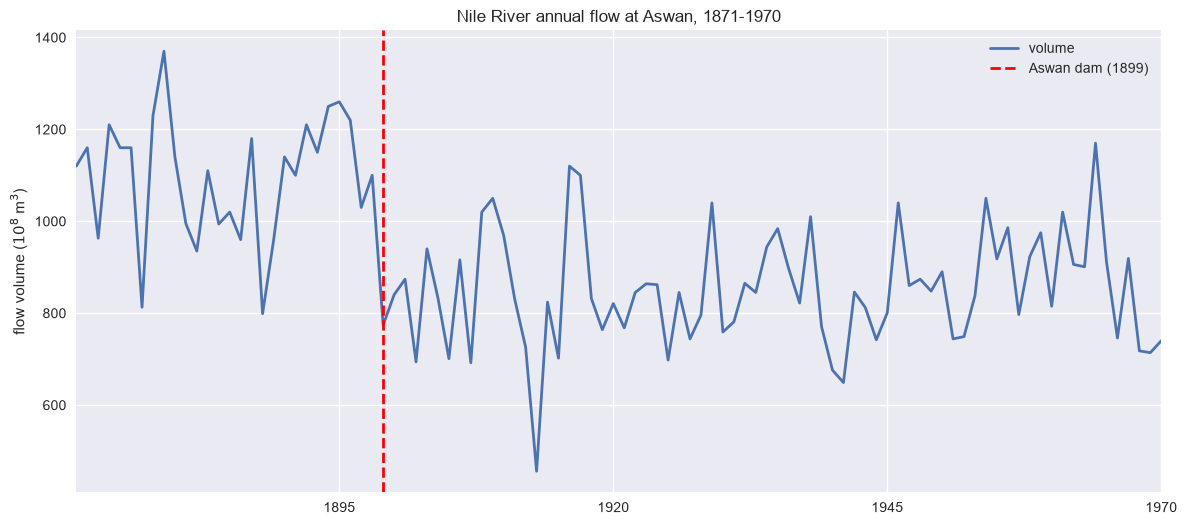

In [38]:
ax = nile_y.plot(lw=2, title="Nile River annual flow at Aswan, 1871-1970")
ax.axvline(pd.Timestamp("1899-01-01"), color="red", linestyle="--", lw=2,
           label="Aswan dam (1899)")
ax.set_xlabel(""); ax.set_ylabel("flow volume ($10^8$ m$^3$)")
plt.legend(); plt.show()

This code generates a line plot visualizing the Nile River’s annual flow data and highlights the construction of the Aswan Dam.

It starts by plotting the `nile_y` time series using the `.plot()` method, creating a line graph with a linewidth of 2 and setting the title to "Nile River annual flow at Aswan, 1871-1970". The resulting axes object is assigned to the variable `ax`.

A vertical line is then added to the plot using `ax.axvline()`, representing the year the Aswan Dam was constructed (1899). This line is colored red, styled as a dashed line, has a linewidth of 2, and includes a label "Aswan dam (1899)".

The x-axis label is removed using `ax.set_xlabel("")`, and the y-axis label is set to “flow volume ($10^8$ m$^3$)”, indicating the units of measurement. Finally, a legend is displayed using `plt.legend()`, and the plot is shown on the screen using `plt.show()`. This visualization allows for a quick understanding of the Nile’s flow pattern over time and highlights the potential impact of the Aswan Dam on the river's hydrology.

In [39]:
print_adf_result(nile_y, name="Nile volume")

ADF test for Nile volume
  ADF statistic : -4.0487
  p-value       : 0.0012
  verdict       : stationary (reject unit root)



This code executes an Augmented Dickey-Fuller (ADF) test on the Nile River annual flow data and prints the results to the console.

It calls the `print_adf_result` function, passing in the `nile_y` time series as input and setting the name of the series to "Nile volume". The function performs the ADF test, calculates the test statistic and p-value, and then prints these values along with a verdict indicating whether the time series is considered stationary or non-stationary based on the significance level of 0.05. This helps determine if the Nile River flow data has a unit root and requires differencing to achieve stationarity before applying certain time series models.

## Hand-built Kalman filter


In [40]:
class DKStateSpaceModel:
    """Minimal Durbin-Koopman Kalman filter for a univariate linear Gaussian model.

        y_t     = Z * alpha_t + eps_t,   eps ~ N(0, H)
        alpha_{t+1} = T * alpha_t + R * eta_t,   eta ~ N(0, Q)

    Scalars throughout (one state, one observation) - enough to see the machinery.
    """
    def __init__(self, y, T, Z, R, Q, H, a1, P1):
        self.y = np.asarray(y, dtype=float)
        self.T, self.Z, self.R = float(T), float(Z), float(R)
        self.Q, self.H = float(Q), float(H)
        self.a1, self.P1 = float(a1), float(P1)
        self.n = len(self.y)

    def filter(self):
        a = np.zeros(self.n + 1)      # predicted state:      a_t = E[alpha_t | y_{1..t-1}]
        P = np.zeros(self.n + 1)      # its variance
        v = np.zeros(self.n)          # innovations
        F = np.zeros(self.n)          # innovation variances
        llc = np.zeros(self.n)        # per-observation log-likelihood contributions
        a[0], P[0] = self.a1, self.P1

        for t in range(self.n):
            # --- prediction of the observation ---
            v[t] = self.y[t] - self.Z * a[t]                  # innovation (surprise)
            F[t] = self.Z * P[t] * self.Z + self.H            # its variance

            # --- Kalman gain and state update, projected to t+1 ---
            K = self.T * P[t] * self.Z / F[t]                 # the gain
            a[t + 1] = self.T * a[t] + K * v[t]
            L = self.T - K * self.Z
            P[t + 1] = self.T * P[t] * L + self.R * self.Q * self.R

            # --- likelihood contribution (prediction error decomposition) ---
            llc[t] = -0.5 * (np.log(2 * np.pi) + np.log(F[t]) + v[t] ** 2 / F[t])

        return a, P, v, F, llc

This code defines a class called `DKStateSpaceModel` that implements a simplified Durbin-Koopman Kalman filter for a univariate linear Gaussian state space model. This is a foundational algorithm in time series analysis used for estimating the unobserved states of a system based on observed data.

The class represents a state space model with the following structure: the observation equation `y_t = Z * alpha_t + eps_t`, where `y_t` is the observed value at time t, `alpha_t` is the hidden state variable, `Z` is an observation matrix, and `eps_t` is a Gaussian noise term. The state transition equation is `alpha_{t+1} = T * alpha_t + R * eta_t`, where `eta_t` is another Gaussian noise term, `T` represents the state transition matrix, and `R` relates the noise to the state.

The `__init__` method initializes the model with parameters like the observed data (`y`), matrices `T`, `Z`, `R`, variances `Q` (state noise) and `H` (observation noise), initial state value `a1`, and initial state covariance `P1`. It also stores the length of the time series in `self.n`.

The `filter` method implements the Kalman filter algorithm itself. It iteratively predicts the state and observation, updates the state based on the observed data, and calculates the likelihood contribution for each observation. 

Inside the loop:
- It first predicts the observation using the current state estimate (`a[t]`).
- Then it computes the innovation (the difference between the actual observation and the predicted observation) and its variance.
- The Kalman gain is calculated to determine how much weight to give to the new observation when updating the state.
- The state is updated based on the Kalman gain and the innovation.
- Finally, the likelihood contribution for that time step is computed, representing how well the model explains the observed data at that point in time.

The method returns arrays containing the predicted states (`a`), their variances (`P`), innovations (`v`), innovation variances (`F`), and per-observation log-likelihood contributions (`llc`). This allows for state estimation, filtering, and assessing the goodness of fit of the model to the observed data. The code is designed for a simple univariate case to clearly illustrate the core Kalman filter mechanics.

In [41]:
# Fit the local level model by MLE (statsmodels), then feed the SAME variances
# to our hand-built filter and check that both engines produce identical output.
uc_ll = sm.tsa.UnobservedComponents(nile_y, level="local level")
uc_res = uc_ll.fit(disp=False)
sigma2_eps, sigma2_eta = uc_res.params
print(f"MLE variances:  measurement sigma2_eps = {sigma2_eps:,.0f}   level sigma2_eta = {sigma2_eta:,.0f}")

# our engine, same parameters, same (approximate diffuse) initialization
ours = DKStateSpaceModel(nile_y.values, T=1, Z=1, R=1,
                         Q=sigma2_eta, H=sigma2_eps, a1=0.0, P1=1e7)
a, P, v, F, llc = ours.filter()

# statsmodels with identical fixed parameters and identical initialization
uc_check = sm.tsa.UnobservedComponents(nile_y, level="local level")
uc_check.initialize_approximate_diffuse(1e7)
sm_fixed = uc_check.smooth([sigma2_eps, sigma2_eta])

print("max |state difference| :", float(np.max(np.abs(a - sm_fixed.predicted_state[0]))))
print("our loglik (after diffuse burn-in):", round(float(llc[1:].sum()), 4))
print("statsmodels loglik                :", round(float(sm_fixed.llf), 4))

MLE variances:  measurement sigma2_eps = 15,078   level sigma2_eta = 1,479
max |state difference| : 5.9117155615240335e-12
our loglik (after diffuse burn-in): -632.5442
statsmodels loglik                : -632.5442


This code verifies the implementation of a custom Kalman filter (`DKStateSpaceModel`) by comparing its output to that of a well-established library function in `statsmodels`. Specifically, it focuses on a local level model for time series data.

First, it fits a local level model to the Nile River flow data using `statsmodels.tsa.UnobservedComponents`. The `fit()` method estimates the variances of the observation noise (`sigma2_eps`) and the state (level) noise (`sigma2_eta`) using maximum likelihood estimation (MLE). These estimated variances are then printed to the console.

Next, it instantiates the custom `DKStateSpaceModel` with the same parameters as the `statsmodels` model – including the estimated variances – along with initial values for the state and its covariance. The filter is then run using the `filter()` method, producing estimates of the state (`a`), its variance (`P`), innovations (`v`), innovation variances (`F`), and log-likelihood contributions (`llc`).

To ensure a fair comparison, another instance of `statsmodels.tsa.UnobservedComponents` is created with identical fixed parameters (the MLE estimated variances) and initialized using an approximate diffuse initialization technique to match the initial conditions of the custom filter. The `smooth()` method then performs smoothing to obtain state estimates from `statsmodels`.

Finally, the code compares the state estimates produced by the two methods, calculating the maximum absolute difference between them. It also calculates and prints the total log-likelihood calculated by both the custom filter (excluding a burn-in period) and the `statsmodels` smoother. The goal is to demonstrate that the custom Kalman filter implementation produces results consistent with those from a validated library function, confirming its correctness. If the maximum state difference and the log-likelihoods are close, it indicates that the custom filter is working as expected.

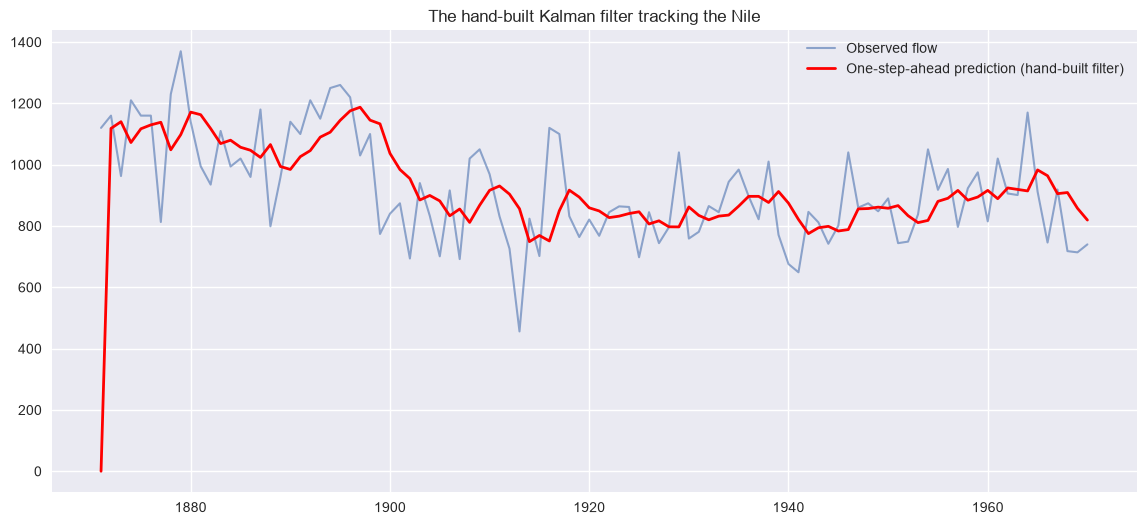

In [42]:
one_step = pd.Series(a[:-1], index=nile_y.index)      # a_t = prediction of y_t before seeing it

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, lw=1.5, alpha=0.6, label="Observed flow")
ax.plot(one_step.index, one_step.values, color="red", lw=2,
        label="One-step-ahead prediction (hand-built filter)")
ax.set_title("The hand-built Kalman filter tracking the Nile")
ax.set_xlabel(""); plt.legend(); plt.show()

This code generates a plot comparing the observed Nile River flow data with one-step-ahead predictions generated by the custom Kalman filter implemented in the `DKStateSpaceModel` class.

It first creates a Pandas Series called `one_step` containing the predicted state values (`a`) from the Kalman filter, excluding the last value (indicated by `[:-1]`). The index of this series is set to match the index of the original Nile River flow data (`nile_y`), ensuring proper alignment for comparison. These predictions represent the best estimate of the current observation *before* it is actually observed.

Then, a Matplotlib figure and axes object are created. The observed Nile River flow data (`nile_y`) is plotted as a semi-transparent line with a linewidth of 1.5, labeled "Observed flow".  The one-step-ahead predictions from the Kalman filter (`one_step`) are then plotted as a solid red line with a linewidth of 2, labeled “One-step-ahead prediction (hand-built filter)”.

Finally, the plot is titled "The hand-built Kalman filter tracking the Nile", the x-axis label is removed, a legend is displayed, and the plot is shown. This visualization allows for a direct assessment of how well the custom Kalman filter tracks the observed data over time, demonstrating its ability to provide accurate short-term predictions.

# The structural ladder

In [43]:
print(uc_res.summary())

                        Unobserved Components Results                         
Dep. Variable:                 volume   No. Observations:                  100
Model:                    local level   Log Likelihood                -632.538
Date:                Thu, 20 Aug 2026   AIC                           1269.076
Time:                        23:50:47   BIC                           1274.266
Sample:                    01-01-1871   HQIC                          1271.176
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.508e+04   2586.506      5.829      0.000       1e+04    2.01e+04
sigma2.level      1478.8117    851.329      1.737      0.082    -189.762    3147.386
Ljung-Box (L1) (Q):         

This code prints a detailed summary of the results from fitting the unobserved components model using `statsmodels`.

Specifically, it calls the `.summary()` method on the fitted `UnobservedComponents` object (`uc_res`). This method generates a comprehensive report that includes:

- Model parameters and their estimated values (e.g., variances of the level and observation noise).
- Standard errors, t-statistics, and p-values for each parameter, indicating the statistical significance of the estimates.
- Confidence intervals for the parameters.
- Information criteria such as AIC, BIC, and HQIC, which can be used to compare different models.
- Log-likelihood value.
- Residual diagnostics, including tests for autocorrelation and heteroscedasticity in the residuals.

The output is a multi-page report printed to the console, providing a thorough assessment of the model’s fit and the reliability of its parameter estimates. This summary is crucial for evaluating the quality of the fitted model and interpreting its results.

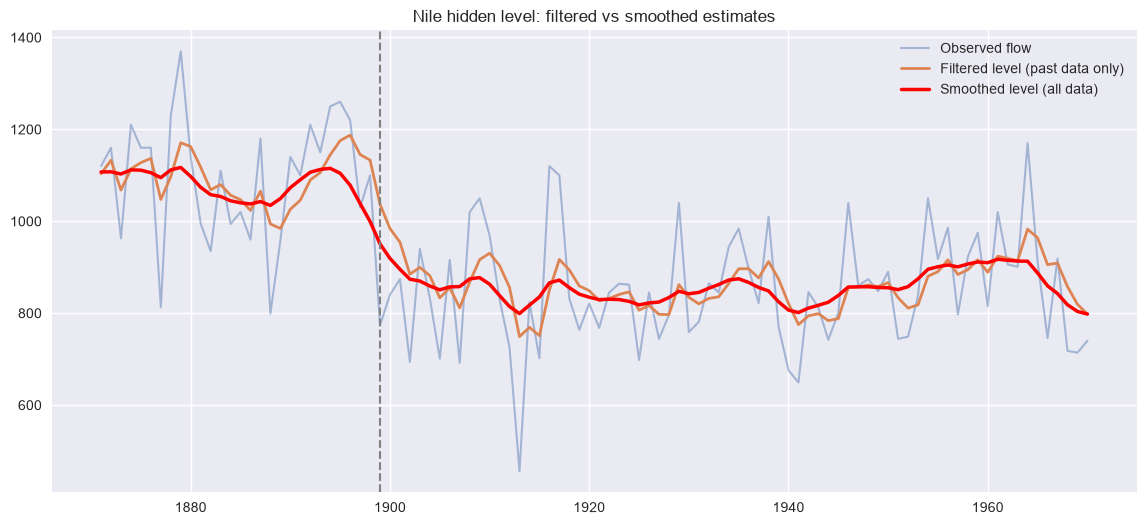

In [44]:
level_filtered = pd.Series(uc_res.level["filtered"], index=nile_y.index)
level_smoothed = pd.Series(uc_res.level["smoothed"], index=nile_y.index)

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, lw=1.5, alpha=0.45, label="Observed flow")
ax.plot(level_filtered.index, level_filtered.values, color="#DD8452", lw=2,
        label="Filtered level (past data only)")
ax.plot(level_smoothed.index, level_smoothed.values, color="red", lw=2.5,
        label="Smoothed level (all data)")
ax.axvline(pd.Timestamp("1899-01-01"), color="grey", linestyle="--", lw=1.5)
ax.set_title("Nile hidden level: filtered vs smoothed estimates")
ax.set_xlabel(""); plt.legend(); plt.show()

This code generates a plot comparing the filtered and smoothed estimates of the underlying level component in the Nile River flow data, as obtained from the `statsmodels` unobserved components model.

It first extracts the filtered and smoothed level estimates from the fitted `UnobservedComponents` object (`uc_res`). The `.level["filtered"]` attribute provides the state estimate based on information available up to that point in time (past data only), while `.level["smoothed"]` uses all available data (past and future) to produce a more accurate, but less timely, estimate. These estimates are then converted into Pandas Series with the same index as the original Nile River flow data (`nile_y`).

A Matplotlib figure and axes object are created. The observed Nile River flow is plotted as a semi-transparent line, labeled "Observed flow".  The filtered level estimate is plotted as a solid line in a salmon color (`#DD8452`), labeled “Filtered level (past data only)”. The smoothed level estimate is then plotted as a thicker red line, labeled “Smoothed level (all data)”.

A vertical dashed gray line is added to indicate the construction of the Aswan Dam. Finally, the plot is titled "Nile hidden level: filtered vs smoothed estimates", the x-axis label is removed, a legend is displayed, and the plot is shown. This visualization illustrates the difference between filtered and smoothed state estimates – the filtered estimate represents the best guess of the underlying level at each point in time based on past data, while the smoothed estimate provides a more accurate retrospective view using all available information.

## Local linear trend 

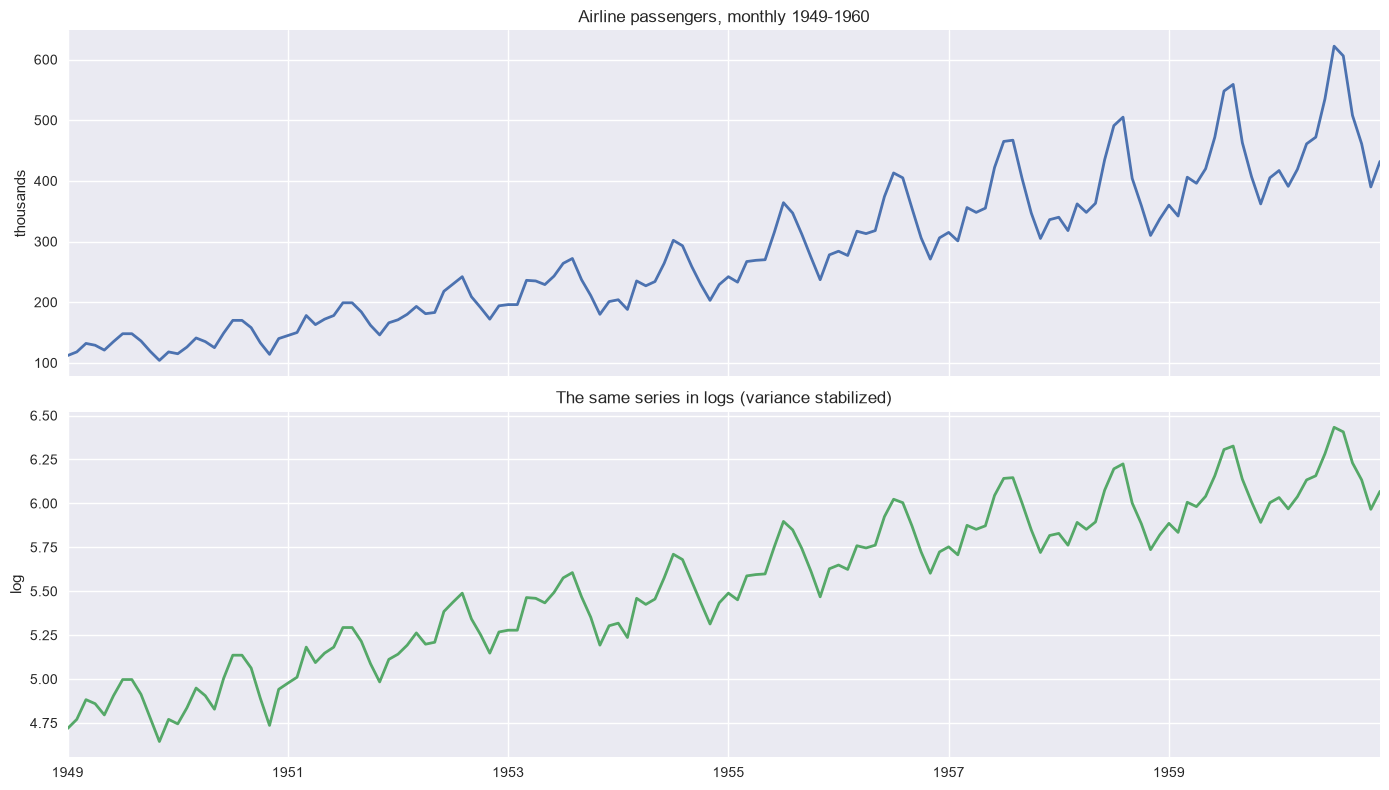

In [45]:
air = pd.read_csv(CFG.data_folder + "passengers.csv")
air["date"] = pd.to_datetime(air["date"])
y_air = air.set_index("date")["passengers"].astype(float).asfreq("MS")
log_air = np.log(y_air)

fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, 8), sharex=True)
y_air.plot(ax=axes[0], lw=2)
axes[0].set(title="Airline passengers, monthly 1949-1960", ylabel="thousands")
log_air.plot(ax=axes[1], lw=2, color="#55A868")
axes[1].set(title="The same series in logs (variance stabilized)", xlabel="", ylabel="log")
plt.tight_layout(); plt.show()

This code loads and prepares the airline passengers dataset for time series analysis, then visualizes both the original data and its logarithmic transformation.

It begins by reading the "passengers.csv" file from the directory specified in `CFG.data_folder` using `pd.read_csv()`. A new column named "date" is created by converting the existing date column to datetime objects using `pd.to_datetime()`. 

The data is then transformed into a time series: it sets the "date" column as the index of the DataFrame and selects the "passengers" column, converts it to a floating-point data type, and resamples it to monthly frequency ("MS") using `.asfreq("MS")`, storing the result in `y_air`. The natural logarithm of the time series is then calculated and stored in `log_air` using `np.log()`. This transformation is often applied to stabilize variance in time series data, making it more suitable for modeling.

Finally, two subplots are created using `plt.subplots(2, 1)`, sharing the x-axis. The original airline passengers data (`y_air`) is plotted on the top subplot with a linewidth of 2 and labeled appropriately. The logarithmic transformation of the data (`log_air`) is plotted on the bottom subplot, also with a linewidth of 2 and a different color (#55A868), and labeled accordingly. `plt.tight_layout()` adjusts subplot parameters for a tight layout, and `plt.show()` displays the resulting plot. This visualization demonstrates the effect of the logarithmic transformation on stabilizing the variance of the time series data.

Local linear trend: {'MAE': 76.41, 'RMSE': 100.68}


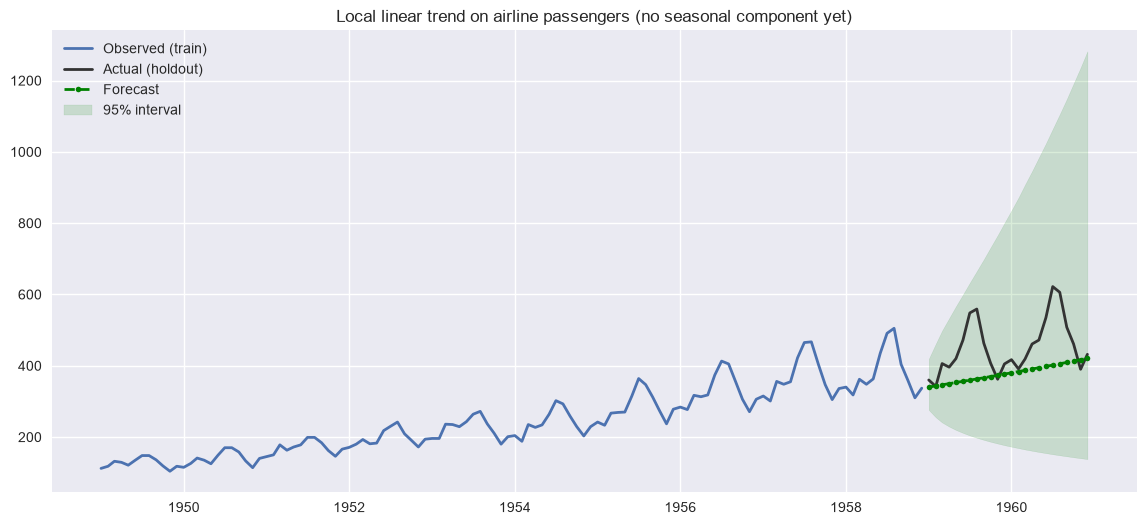

In [46]:
log_train, log_valid = train_valid_split(log_air)
valid_orig = y_air.iloc[-CFG.HORIZON:]                  # holdout on the original scale

llt_res = sm.tsa.UnobservedComponents(log_train, level="local linear trend").fit(disp=False)

fc = llt_res.get_forecast(CFG.HORIZON)
llt_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("Local linear trend:", forecast_metrics(valid_orig, llt_pred))
plot_forecast(y_air.iloc[:-CFG.HORIZON], valid_orig, llt_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="Local linear trend on airline passengers (no seasonal component yet)")

This code fits a local linear trend model to the logarithm of the airline passenger data and evaluates its forecasting performance.

First, it splits the logarithmic time series (`log_air`) into training and validation sets using the `train_valid_split` function, reserving the last `CFG.HORIZON` months for validation. It also stores the original scale values of the validation set in `valid_orig` to allow for performance evaluation on the original units.

A local linear trend model is then fitted to the training data (`log_train`) using `statsmodels.tsa.UnobservedComponents`. The `fit()` method estimates the model parameters, and `disp=False` suppresses output during fitting. 

Next, it generates forecasts for the validation period using the `get_forecast()` method of the fitted model, specifying the forecast horizon (`CFG.HORIZON`). The predicted mean is exponentiated (`np.exp()`) to convert the forecast back to the original scale (passengers). Confidence intervals are also calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of the model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`llt_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. 

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the training data, the actual validation data, the forecasted values, and the confidence intervals. The plot is titled "Local linear trend on airline passengers (no seasonal component yet)". This allows for visual assessment of the model’s fit and forecasting accuracy.

## Basic structural model 

Basic structural model: {'MAE': 27.72, 'RMSE': 32.58}

estimated variances:
  sigma2.irregular     0.000141
  sigma2.level         0.000797
  sigma2.trend         0.000000
  sigma2.seasonal      0.000037


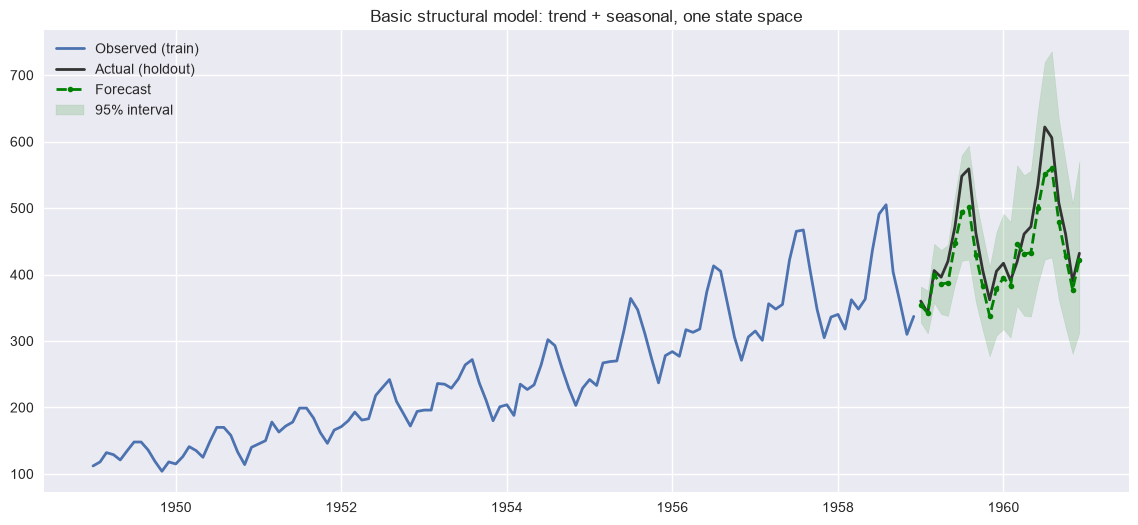

In [47]:
bsm_res = sm.tsa.UnobservedComponents(
    log_train,
    level="local linear trend",
    seasonal=CFG.SEASONAL_PERIODS,
).fit(disp=False)

fc = bsm_res.get_forecast(CFG.HORIZON)
bsm_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("Basic structural model:", forecast_metrics(valid_orig, bsm_pred))
print("\nestimated variances:")
for name, val in zip(bsm_res.param_names, bsm_res.params):
    print(f"  {name:20s} {val:.6f}")

plot_forecast(y_air.iloc[:-CFG.HORIZON], valid_orig, bsm_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="Basic structural model: trend + seasonal, one state space")

This code fits a basic structural time series model with both trend and seasonality to the logarithm of the airline passenger data and evaluates its forecasting performance.

It begins by fitting an unobserved components model using `statsmodels.tsa.UnobservedComponents` to the training data (`log_train`). This time, it specifies both a local linear trend (`level="local linear trend"`) and a seasonal component with a period of `CFG.SEASONAL_PERIODS` (12 for monthly data with an annual cycle). The model is fitted using the `fit()` method, suppressing output during fitting.

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`CFG.HORIZON`).  The predicted mean is exponentiated to convert it back to the original scale (passengers), and confidence intervals are calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`bsm_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. 

Additionally, it prints a list of estimated variances from the fitted model by iterating through the parameter names (`bsm_res.param_names`) and their corresponding values (`bsm_res.params`), formatting them for readability. This provides insight into the relative importance of different components in the model.

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the training data, actual validation data, forecasted values, and confidence intervals. The plot is titled "Basic structural model: trend + seasonal, one state space". This visualization allows for assessment of how well the inclusion of seasonality improves forecasting accuracy compared to the local linear trend model alone.

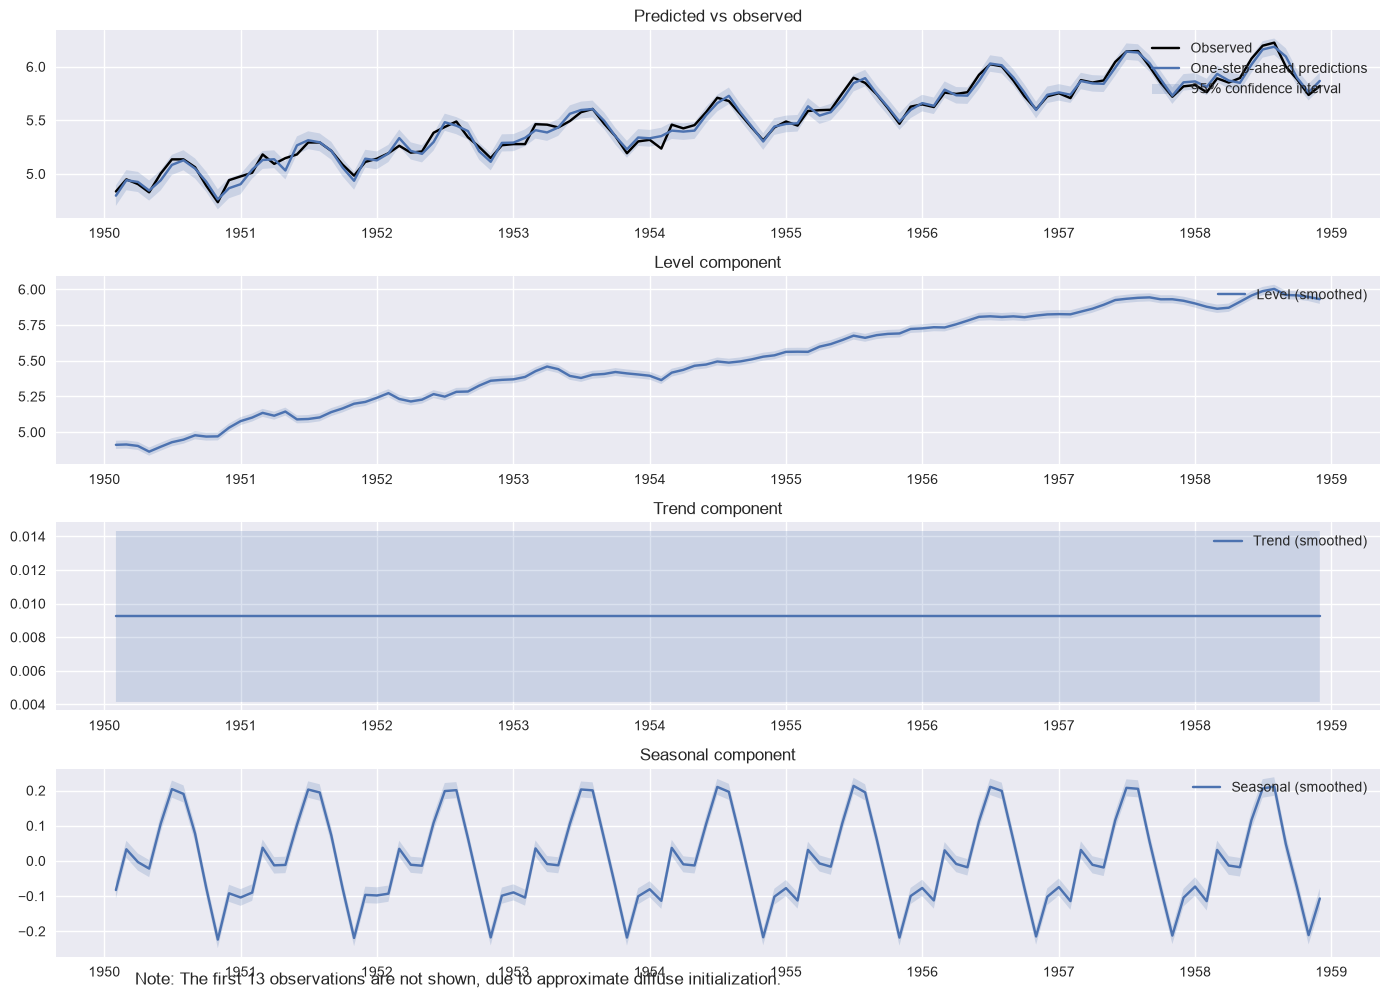

In [48]:
fig = bsm_res.plot_components(figsize=(CFG.img_dim1, CFG.img_dim2 + 4))
plt.tight_layout(); plt.show()

This code generates a plot displaying the components of the basic structural time series model fitted to the airline passenger data.

It calls the `plot_components()` method on the fitted `bsm_res` object (the result of fitting the unobserved components model). This method automatically creates a figure with subplots showing the estimated trend, seasonal, and irregular components of the time series. The `figsize` argument sets the size of the figure to match the configuration settings defined in `CFG`.

`plt.tight_layout()` adjusts subplot parameters for a tight layout, preventing overlapping elements. Finally, `plt.show()` displays the resulting plot. This visualization provides valuable insights into how the model decomposes the time series into its underlying components and helps understand the dynamics of the data.

# Unification

## ARIMA as a state space model (SARIMAX)

SARIMAX airline model: {'MAE': 39.45, 'RMSE': 43.19}


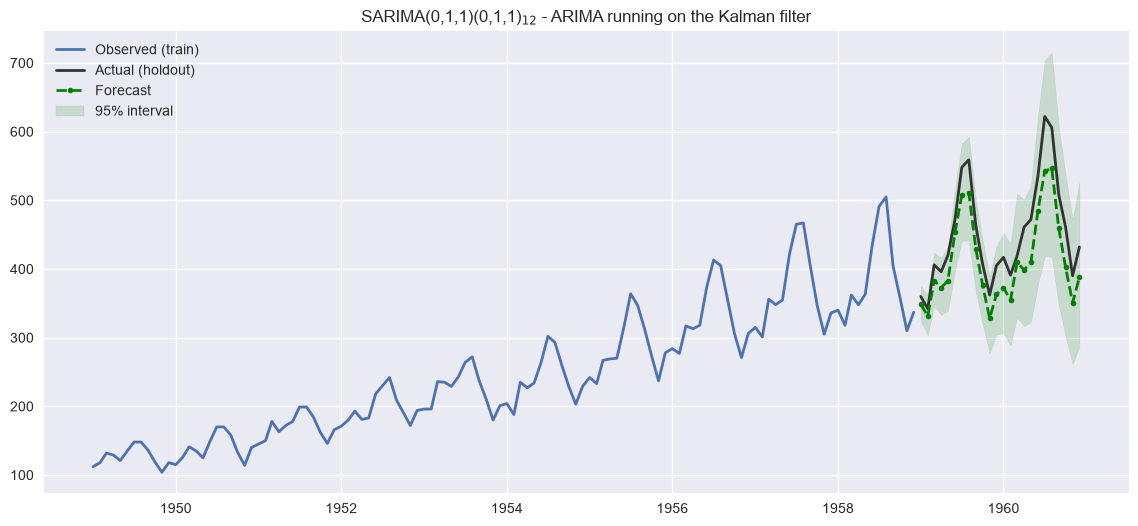

In [49]:
sarimax_res = sm.tsa.SARIMAX(log_train, order=(0, 1, 1),
                             seasonal_order=(0, 1, 1, CFG.SEASONAL_PERIODS)).fit(disp=False)

fc = sarimax_res.get_forecast(CFG.HORIZON)
sarimax_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("SARIMAX airline model:", forecast_metrics(valid_orig, sarimax_pred))
plot_forecast(y_air.iloc[:-CFG.HORIZON], valid_orig, sarimax_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="SARIMA(0,1,1)(0,1,1)$_{12}$ - ARIMA running on the Kalman filter")

This code fits a Seasonal Autoregressive Integrated Moving Average (SARIMAX) model to the logarithm of the airline passenger data and evaluates its forecasting performance.

It begins by fitting a SARIMAX model using `sm.tsa.SARIMAX` to the training data (`log_train`). The model is specified with an order of (0, 1, 1), representing zero autoregressive terms, one integration (differencing) term, and one moving average term. It also includes a seasonal component with an order of (0, 1, 1, `CFG.SEASONAL_PERIODS`), indicating zero seasonal autoregressive terms, one seasonal differencing term, one seasonal moving average term, and a seasonal period of 12 (monthly data with an annual cycle). The model is fitted using the `fit()` method, suppressing output during fitting.

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`CFG.HORIZON`).  The predicted mean is exponentiated to convert it back to the original scale (passengers), and confidence intervals are calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`sarimax_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. 

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the training data, actual validation data, forecasted values, and confidence intervals. The plot is titled "SARIMA(0,1,1)(0,1,1)$_{12}$ - ARIMA running on the Kalman filter". This visualization allows for assessment of how well the SARIMAX model captures both the trend and seasonal patterns in the airline passenger data and provides a comparison to the previously fitted structural time series models.

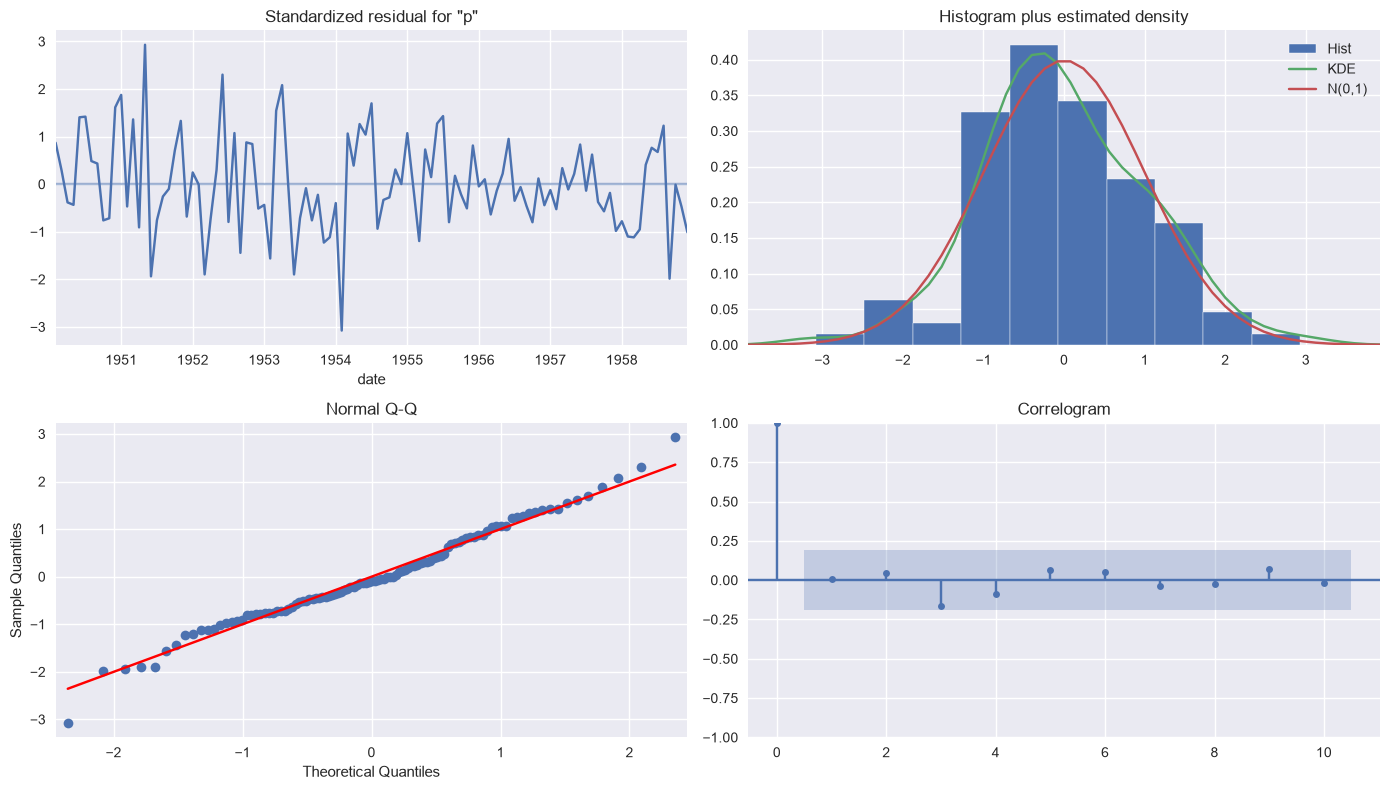

In [50]:
sarimax_res.plot_diagnostics(figsize=(CFG.img_dim1, CFG.img_dim2 + 2))
plt.tight_layout(); plt.show()

This code generates diagnostic plots for the fitted SARIMAX model to assess its adequacy and identify potential issues with the model fit.

It calls the `plot_diagnostics()` method on the fitted `sarimax_res` object (the result of fitting the SARIMAX model). This method automatically creates a figure containing several subplots designed to check various assumptions of the model, including:

- Autocorrelation and partial autocorrelation functions (ACF and PACF) of the residuals to assess whether any serial correlation remains.
- A histogram or density plot of the standardized residuals to check for normality.
- Q-Q plots to further evaluate the normality of the residuals.
- Plots of the residuals over time to identify potential patterns or heteroscedasticity (non-constant variance).

The `figsize` argument sets the size of the figure to match the configuration settings defined in `CFG`.  `plt.tight_layout()` adjusts subplot parameters for a tight layout, and `plt.show()` displays the resulting plot. These diagnostic plots are crucial for validating the model assumptions and ensuring that the SARIMAX model provides a reliable representation of the data.

## Exponential smoothing as a state space model (ETS / SSOE)

In [51]:
ets_res = ETSModel(log_train, error="add", trend="add", seasonal="add",
                   seasonal_periods=CFG.SEASONAL_PERIODS).fit(disp=False)

print("smoothing parameters (a.k.a. steady-state Kalman gains):")
for name, val in zip(ets_res.param_names, ets_res.params):
    if "smoothing" in name:
        print(f"  {name:22s} {val:.4f}")

ets_pred = np.exp(ets_res.forecast(CFG.HORIZON))
print("\nETS(A,A,A):", forecast_metrics(valid_orig, ets_pred))

smoothing parameters (a.k.a. steady-state Kalman gains):
  smoothing_level        0.9999
  smoothing_trend        0.0001
  smoothing_seasonal     0.0001

ETS(A,A,A): {'MAE': 31.77, 'RMSE': 36.95}


This code fits an Exponential Smoothing State Space (ETS) model to the logarithm of the airline passenger data and evaluates its forecasting performance.

It begins by fitting an ETS model using `statsmodels.tsa.exponential_smoothing.ets.ETSModel` to the training data (`log_train`). The model is specified with additive error, additive trend, and additive seasonality components (error="add", trend="add", seasonal="add").  The seasonal period is set to `CFG.SEASONAL_PERIODS` (12 for monthly data). The model is fitted using the `fit()` method, suppressing output during fitting.

Next, it prints the estimated smoothing parameters of the ETS model. These parameters, also known as steady-state Kalman gains, control how much weight is given to recent observations versus past estimates when updating the level, trend, and seasonal components. It iterates through the parameter names (`ets_res.param_names`) and values (`ets_res.params`), printing only those parameters that contain "smoothing" in their name, formatted for readability.

Forecasts are then generated for the validation period using the `forecast()` method of the fitted ETS model, specifying the forecast horizon (`CFG.HORIZON`). The forecasted values are exponentiated to convert them back to the original scale (passengers). 

Finally, the forecasting performance of the ETS model is evaluated using the `forecast_metrics` function, comparing the forecasts (`ets_pred`) to the actual validation data on the original scale (`valid_orig`). The resulting MAE and RMSE are printed to the console. This provides a measure of how well the ETS model captures the underlying patterns in the airline passenger data and makes accurate predictions.

# Custom models with MLEModel

In [52]:
class LocalLinearTrend(MLEModel):
    """Local linear trend written directly in system matrices.

    state:  (mu_t, nu_t)        level and slope
    params: three variances (measurement, level shock, slope shock)
    """
    param_names = ["sigma2.irregular", "sigma2.level", "sigma2.trend"]
    start_params = [1.0, 1.0, 1.0]

    def __init__(self, endog):
        super().__init__(endog, k_states=2, k_posdef=2,
                         initialization="approximate_diffuse")
        self["design"] = np.array([[1.0, 0.0]])            # y_t = mu_t + eps
        self["transition"] = np.array([[1.0, 1.0],         # mu_{t+1} = mu_t + nu_t
                                       [0.0, 1.0]])        # nu_{t+1} = nu_t
        self["selection"] = np.eye(2)                      # each state gets its own shock

    def transform_params(self, unconstrained):
        return unconstrained ** 2                          # keep variances positive

    def untransform_params(self, constrained):
        return constrained ** 0.5

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]                  # H
        self["state_cov", 0, 0] = params[1]                # Q: level shock
        self["state_cov", 1, 1] = params[2]                # Q: slope shock

This code defines a custom state space model class called `LocalLinearTrend` that implements a local linear trend model directly using system matrices. This allows for greater control and flexibility in defining the model structure compared to using pre-built functions.

The class inherits from `statsmodels.tsa.statespace.mlemodel.MLEModel`, providing a framework for maximum likelihood estimation. It represents a state space model with two states: `mu_t` representing the level (the current value of the time series) and `nu_t` representing the slope (the rate of change in the level). The model has three parameters, which are variances: `sigma2.irregular` (variance of the observation noise), `sigma2.level` (variance of the level shock), and `sigma2.trend` (variance of the slope shock).

The `param_names` attribute defines the names of these parameters for reporting purposes. The `start_params` attribute provides initial values for the parameters used during optimization.

The `__init__` method initializes the model with the observed data (`endog`). It sets the number of states to 2 and the number of positive definite parameters to 2, and uses an approximate diffuse initialization scheme.  It then defines three key matrices:
- `"design"`: This matrix relates the state variables to the observation equation (y_t = mu_t + eps).
- `"transition"`: This matrix describes how the states evolve over time (mu_{t+1} = mu_t + nu_t, nu_{t+1} = nu_t).
- `"selection"`: This matrix determines which state variables are affected by the noise terms.

The `transform_params` method transforms unconstrained parameters to constrained ones (in this case, ensuring variances are positive) by squaring them. The `untransform_params` method performs the inverse transformation, taking the square root of the constrained parameters. 

Finally, the `update` method updates the model’s covariance matrices based on the estimated parameters. It sets the observation covariance (`obs_cov`) to the irregular variance and the state covariances (`state_cov`) to the level and slope variances, respectively. This class provides a flexible way to define and estimate a local linear trend model within the `statsmodels` framework.

In [53]:
custom_res = LocalLinearTrend(log_train).fit(disp=False)

check = pd.DataFrame({
    "custom MLEModel": np.round(custom_res.params, 6),
    "UnobservedComponents": np.round(llt_res.params, 6),
}, index=custom_res.param_names)
check

,custom MLEModel,UnobservedComponents
sigma2.irregular,0.000000,0.000000
sigma2.level,0.011203,0.011203
sigma2.trend,0.000000,0.000000


This code fits the custom `LocalLinearTrend` model to the logarithm of the airline passenger data and compares its estimated parameters with those obtained from the `statsmodels` unobserved components model (specifically, the local linear trend model fitted earlier).

It begins by instantiating the `LocalLinearTrend` class with the training data (`log_train`) and fitting it using the `fit()` method, suppressing output during fitting. 

Next, it creates a Pandas DataFrame called `check` to compare the estimated parameters from both models. The DataFrame has two columns: "custom MLEModel" containing the parameter estimates from the custom model (`custom_res.params`), and "UnobservedComponents" containing the corresponding parameter estimates from the `llt_res` object (the fitted unobserved components model). 

The parameter estimates are rounded to six decimal places using `np.round()` for easier comparison. The index of the DataFrame is set to `custom_res.param_names`, ensuring that the parameters are labeled correctly in both columns. Finally, the code displays the resulting DataFrame, allowing a direct side-by-side comparison of the parameter estimates from the custom implementation and the established `statsmodels` function. This serves as a crucial validation step, confirming that the custom model is producing results consistent with those from a well-tested library function.

# Application: missing data, handled natively

In [54]:
GAP_START, GAP_END = 40, 55                    # hide 15 consecutive years

nile_gapped = nile_y.copy().astype(float)
nile_gapped.iloc[GAP_START:GAP_END] = np.nan
hidden_truth = nile_y.iloc[GAP_START:GAP_END]
print(f"gap: {nile_gapped.index[GAP_START].year}-{nile_gapped.index[GAP_END-1].year}"
      f"  ({GAP_END - GAP_START} missing years)")

gap_res = sm.tsa.UnobservedComponents(nile_gapped, level="local level").fit(disp=False)

print("\nvariances fitted on gapped data :", np.round(gap_res.params, 0).astype(int).tolist())
print("variances fitted on full data   :", np.round(uc_res.params, 0).astype(int).tolist())

gap: 1911-1925  (15 missing years)

variances fitted on gapped data : [12813, 1870]
variances fitted on full data   : [15078, 1479]


This code introduces a gap in the Nile River flow dataset and compares the estimated variances of an unobserved components model fitted to both the gapped and complete datasets.

It first defines `GAP_START` and `GAP_END` as 40 and 55, respectively, indicating the indices where a gap will be introduced into the time series. This corresponds to hiding 15 consecutive years of data.

A copy of the original Nile River flow data (`nile_y`) is created and converted to a floating-point type, stored in `nile_gapped`. The values within the specified gap (from `GAP_START` to `GAP_END`) are then replaced with NaN (Not a Number) values, effectively creating missing data.  The original values that were removed during the gap creation are saved into `hidden_truth` for later comparison. A message is printed indicating the years covered by the gap and the number of missing years.

An unobserved components model with a local level component is then fitted to the gapped time series (`nile_gapped`) using `statsmodels.tsa.UnobservedComponents`. The `fit()` method estimates the model parameters, suppressing output during fitting.

Finally, it prints the estimated variances from both the model fitted to the gapped data (`gap_res.params`) and the model fitted to the full (ungapped) data (`uc_res.params`). These variances are rounded to the nearest integer using `np.round(..., 0).astype(int)` and converted into a list for easier readability. This comparison allows assessing how the introduction of missing data affects the estimated variances of the underlying components in the time series, providing insights into the robustness of the model to gaps in the data.

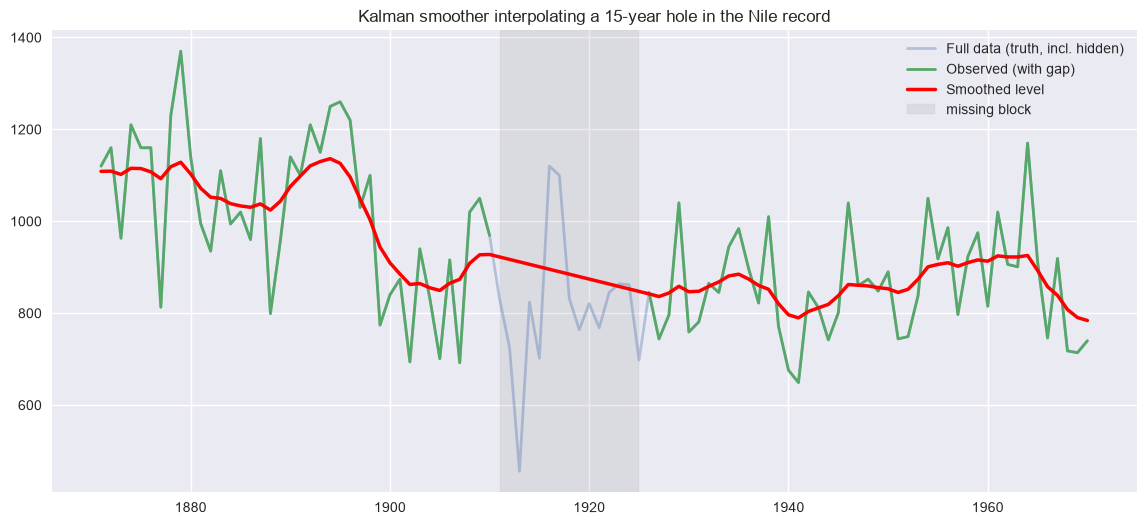

RMSE inside the gap - Kalman smoother   : 172.25
RMSE inside the gap - linear interpolation: 185.15


In [55]:
interp = pd.Series(gap_res.level["smoothed"], index=nile_gapped.index)
gap_slice = slice(GAP_START, GAP_END)

fig, ax = plt.subplots()
ax.plot(nile_y.index, nile_y.values, lw=2, alpha=0.35, label="Full data (truth, incl. hidden)")
ax.plot(nile_gapped.index, nile_gapped.values, lw=2, label="Observed (with gap)")
ax.plot(interp.index, interp.values, color="red", lw=2.5, label="Smoothed level")
ax.axvspan(nile_y.index[GAP_START], nile_y.index[GAP_END - 1], color="grey", alpha=0.15,
           label="missing block")
ax.set_title("Kalman smoother interpolating a 15-year hole in the Nile record")
ax.set_xlabel(""); plt.legend(); plt.show()

kalman_rmse = forecast_metrics(hidden_truth, interp.iloc[gap_slice])["RMSE"]
naive_rmse = forecast_metrics(hidden_truth, nile_gapped.interpolate().iloc[gap_slice])["RMSE"]
print("RMSE inside the gap - Kalman smoother   :", kalman_rmse)
print("RMSE inside the gap - linear interpolation:", naive_rmse)

This code visualizes and evaluates the performance of a Kalman smoother in interpolating missing data within the Nile River flow time series, comparing it to simple linear interpolation.

It first extracts the smoothed level estimates from the unobserved components model fitted to the gapped data (`gap_res`) and creates a Pandas Series called `interp` with the same index as the gapped data (`nile_gapped`). This represents the Kalman smoother’s estimate of the underlying trend during the period where data is missing.

A plot is then generated using Matplotlib. The full, original Nile River flow data is plotted as a semi-transparent line, labeled "Full data (truth, incl. hidden)". The gapped data (`nile_gapped`) is plotted as a solid line, labeled “Observed (with gap)”.  The smoothed level estimates from the Kalman smoother (`interp`) are plotted as a thicker red line, labeled “Smoothed level”. A shaded gray region highlights the period where data is missing. The plot is titled "Kalman smoother interpolating a 15-year hole in the Nile record".

Next, it calculates and prints the Root Mean Squared Error (RMSE) between the Kalman smoother’s interpolation (`interp`) and the original, hidden values within the gap (`hidden_truth`). It also calculates and prints the RMSE of simple linear interpolation applied to the gapped data using `nile_gapped.interpolate()`. The comparison is limited to the slice corresponding to the missing period (`gap_slice`).

This allows for a quantitative assessment of how well the Kalman smoother performs in filling in the gaps compared to a naive linear interpolation approach. A lower RMSE indicates better accuracy in reconstructing the missing data.

# Head-to-head 1

In [56]:
scores = {
    "LocalLinearTrend (no seasonal)": forecast_metrics(valid_orig, llt_pred)["RMSE"],
    "BasicStructural": forecast_metrics(valid_orig, bsm_pred)["RMSE"],
    "SARIMAX airline": forecast_metrics(valid_orig, sarimax_pred)["RMSE"],
    "ETS(A,A,A)": forecast_metrics(valid_orig, ets_pred)["RMSE"],
}
compare_models(scores, baseline="LocalLinearTrend (no seasonal)")

,RMSE,delta_vs_baseline,improved
model,,,
BasicStructural,32.58,-68.10,True
"ETS(A,A,A)",36.95,-63.73,True
SARIMAX airline,43.19,-57.49,True
LocalLinearTrend (no seasonal),100.68,0.00,False


This code summarizes and compares the forecasting performance of several different time series models on the airline passenger data.

It first creates a dictionary called `scores` where keys are model names and values are their corresponding Root Mean Squared Error (RMSE) scores calculated using the `forecast_metrics` function. The models included in the comparison are: Local Linear Trend (without seasonality), Basic Structural Model, SARIMAX, and ETS(A,A,A).

Then, it calls the `compare_models` function with the `scores` dictionary and specifies the "LocalLinearTrend (no seasonal)" model as the baseline. The `compare_models` function generates a Pandas DataFrame that displays each model’s RMSE, its difference from the baseline RMSE, and a boolean flag indicating whether the model performed better than the baseline. The DataFrame is sorted by RMSE in ascending order, making it easy to identify the best-performing models relative to the baseline. This provides a concise and informative comparison of the forecasting accuracy of different time series modeling techniques.

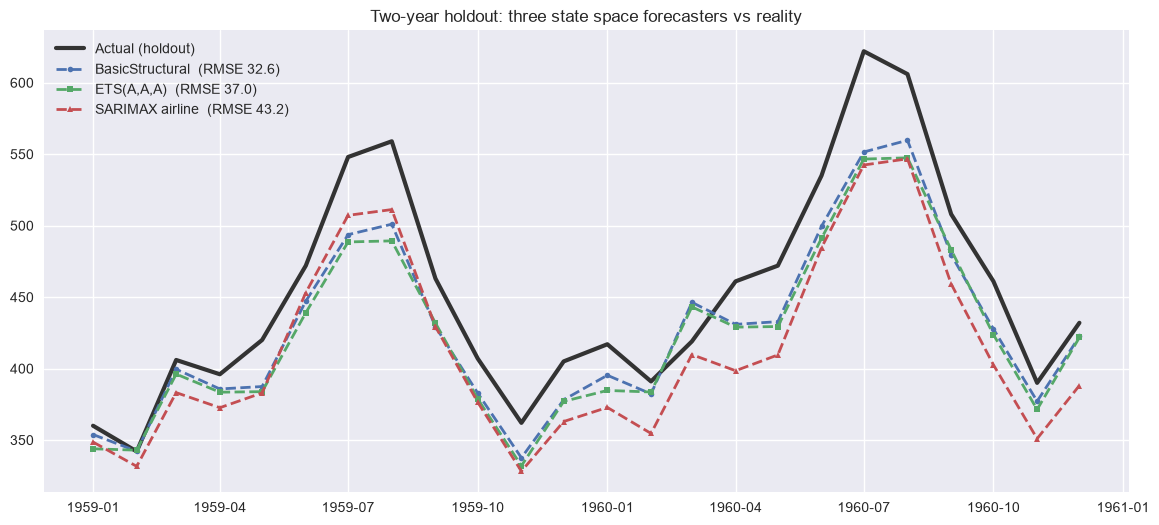

In [57]:
fig, ax = plt.subplots()
ax.plot(valid_orig.index, valid_orig.values, lw=3, color="#333333", label="Actual (holdout)")
ax.plot(valid_orig.index, bsm_pred.values, lw=2, linestyle="--", marker="o", markersize=4,
        label=f"BasicStructural  (RMSE {scores['BasicStructural']:.1f})")
ax.plot(valid_orig.index, ets_pred.values, lw=2, linestyle="--", marker="s", markersize=4,
        label=f"ETS(A,A,A)  (RMSE {scores['ETS(A,A,A)']:.1f})")
ax.plot(valid_orig.index, sarimax_pred.values, lw=2, linestyle="--", marker="^", markersize=4,
        label=f"SARIMAX airline  (RMSE {scores['SARIMAX airline']:.1f})")
ax.set_title("Two-year holdout: three state space forecasters vs reality")
ax.set_xlabel(""); plt.legend(); plt.show()

This code generates a plot comparing the forecasts from three different time series models (Basic Structural, ETS(A,A,A), and SARIMAX) to the actual values in the validation set of the airline passenger data.

It creates a Matplotlib figure and axes object. The actual validation data (`valid_orig`) is plotted as a thick gray line, labeled "Actual (holdout)". 

The forecasts from each model are then plotted on the same graph:
- Basic Structural Model’s forecast (`bsm_pred`) is plotted as a dashed line with circle markers, and its RMSE score is included in the label.
- ETS(A,A,A) model’s forecast (`ets_pred`) is plotted as a dashed line with square markers, and its RMSE score is included in the label.
- SARIMAX airline model’s forecast (`sarimax_pred`) is plotted as a dashed line with triangle markers, and its RMSE score is included in the label.

The plot is titled "Two-year holdout: three state space forecasters vs reality", the x-axis label is removed, and a legend is displayed to identify each model’s forecast. This visualization allows for a direct comparison of the forecasting performance of the different models on the validation data, providing insights into their strengths and weaknesses. The inclusion of RMSE scores in the labels further facilitates this comparison.

# Head to head 2

913,000 rows | 10 stores x 50 items
aggregated: 1,826 daily observations, 2013-01-01 to 2017-12-31, 0 missing


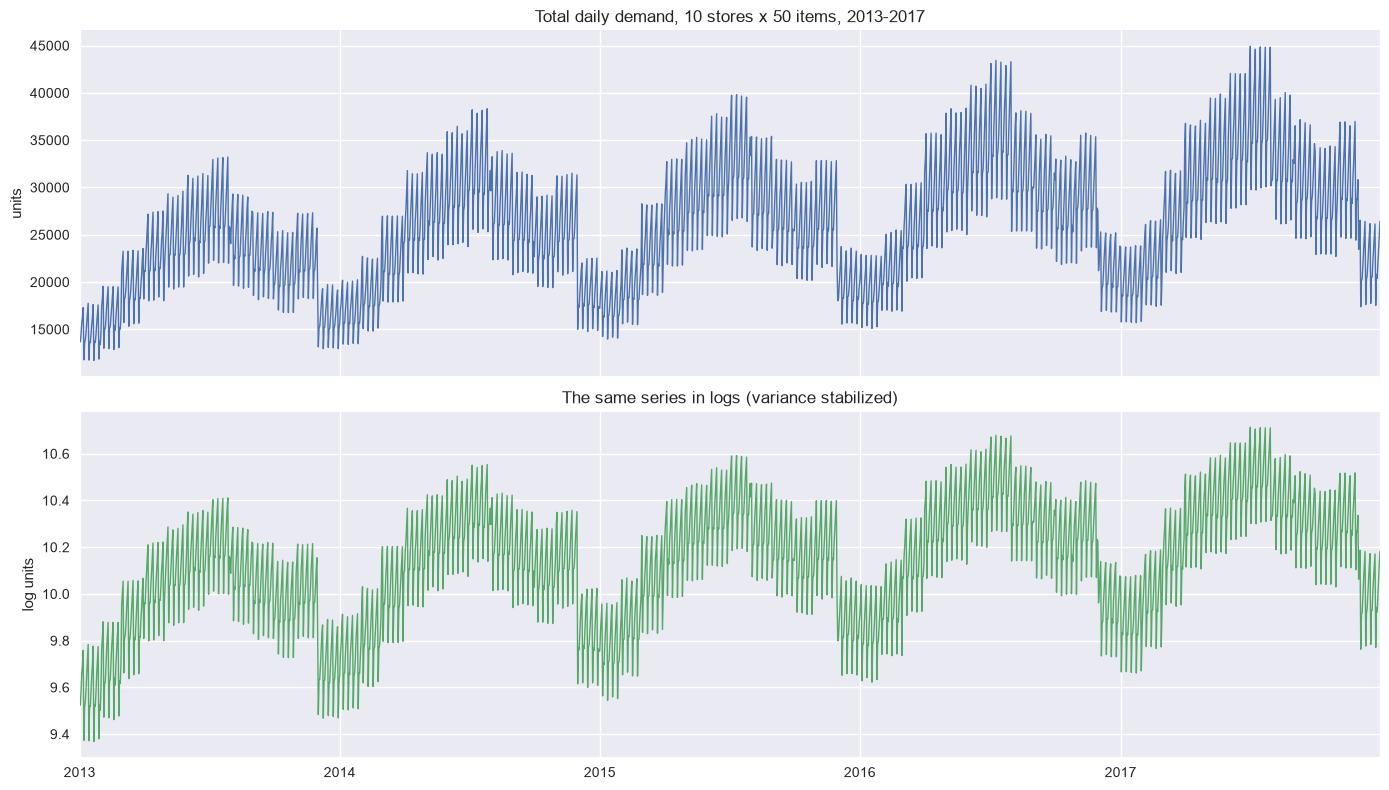

In [58]:
# constants for this section
HORIZON2 = 90            # days held out - roughly one business quarter
WEEKLY_PERIOD = 7        # day-of-week cycle
ANNUAL_PERIOD = 365.25   # yearly cycle in days (the .25 accounts for leap years)

sales = pd.read_csv(CFG.data_folder + "train.csv", parse_dates=["date"])
print(f"{len(sales):,} rows | {sales['store'].nunique()} stores x {sales['item'].nunique()} items")

# collapse the 500 store-item series into total chain-wide daily demand
demand = sales.groupby("date")["sales"].sum().asfreq("D")
log_demand = np.log(demand)
print(f"aggregated: {len(demand):,} daily observations, "
      f"{demand.index.min():%Y-%m-%d} to {demand.index.max():%Y-%m-%d}, "
      f"{demand.isna().sum()} missing")

fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, 8), sharex=True)
demand.plot(ax=axes[0], lw=1)
axes[0].set(title="Total daily demand, 10 stores x 50 items, 2013-2017", ylabel="units")
log_demand.plot(ax=axes[1], lw=1, color="#55A868")
axes[1].set(title="The same series in logs (variance stabilized)", xlabel="", ylabel="log units")
plt.tight_layout(); plt.show()

This code loads and prepares a retail sales dataset for time series analysis, focusing on aggregated daily demand across multiple stores and items.

It begins by defining constants: `HORIZON2` representing the length of the holdout period in days (90, roughly one business quarter), `WEEKLY_PERIOD` set to 7 for the day-of-week cycle, and `ANNUAL_PERIOD` set to 365.25 to account for leap years.

The sales data is loaded from a CSV file using `pd.read_csv()`, with the "date" column parsed as datetime objects. The code then prints information about the dataset’s size: the number of rows, the number of unique stores, and the number of unique items.

Next, it aggregates the sales data to calculate total chain-wide daily demand by grouping by date and summing the sales values. The resulting time series is resampled to a daily frequency ("D") using `asfreq()`.  The natural logarithm of the aggregated demand is then calculated and stored in `log_demand` for variance stabilization.

Information about the aggregated data is printed, including the number of observations, the start and end dates of the time series, and the number of missing values. 

Finally, two subplots are created to visualize the original and log-transformed demand data. The total daily demand is plotted on the top subplot, while the log-transformed demand is plotted on the bottom subplot. Both plots have appropriate titles and labels. This prepares the retail sales data for further analysis and forecasting.

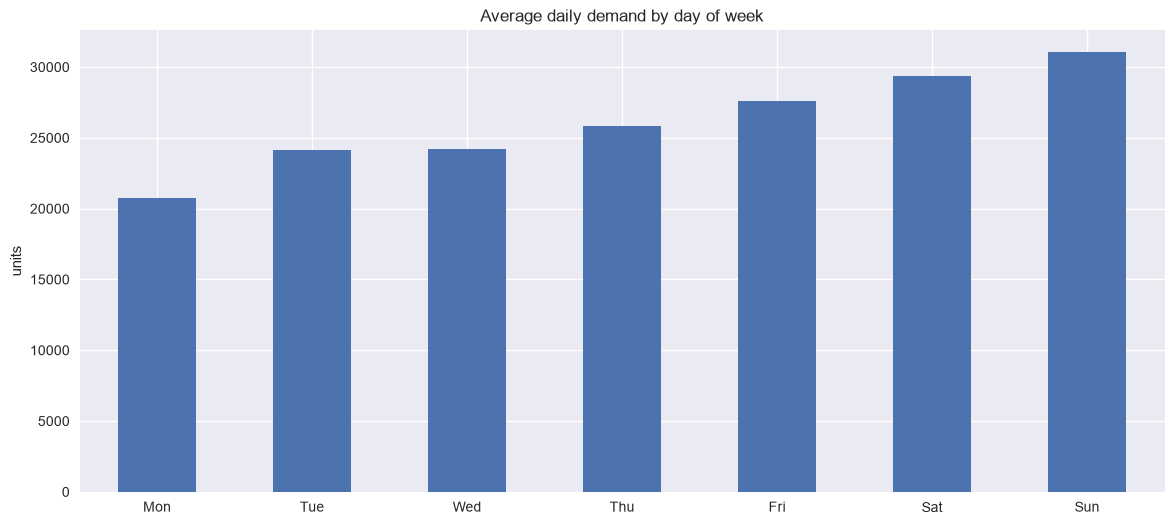

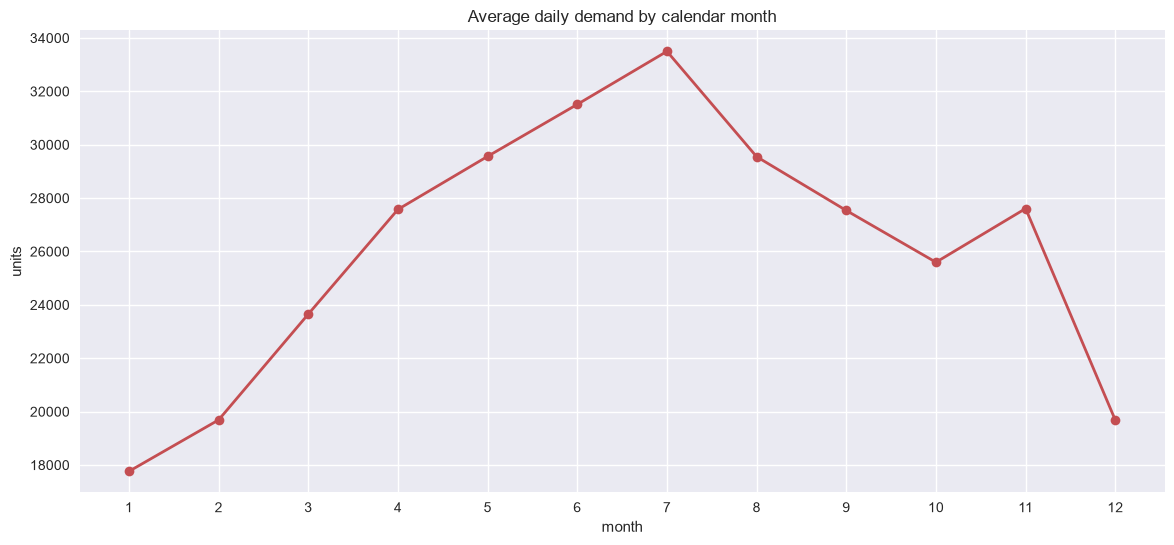

In [59]:
# average demand by day of week
weekly_profile = demand.groupby(demand.index.dayofweek).mean()
weekly_profile.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax = weekly_profile.plot(kind="bar", rot=0, color="#4C72B0",
                         title="Average daily demand by day of week")
ax.set_ylabel("units"); plt.show()

# average demand by calendar month
monthly_profile = demand.groupby(demand.index.month).mean()
ax = monthly_profile.plot(marker="o", lw=2, color="#C44E52",
                          title="Average daily demand by calendar month")
ax.set(xlabel="month", ylabel="units", xticks=range(1, 13)); plt.show()

This code analyzes and visualizes the seasonal patterns in the retail sales data by examining average demand by day of week and calendar month.

First, it calculates the average daily demand for each day of the week using `demand.groupby(demand.index.dayofweek).mean()`. The index is then relabeled with the corresponding day names ("Mon", "Tue", etc.). A bar chart is created to visualize this weekly profile, showing the average demand for each day of the week.

Next, it calculates the average daily demand for each calendar month using `demand.groupby(demand.index.month).mean()`. A line plot with markers is generated to display this monthly profile, illustrating how demand varies throughout the year. The x-axis ticks are set to represent the months from 1 to 12.

These visualizations help identify potential weekly and annual seasonal patterns in the sales data, which can be valuable for forecasting and inventory management. For example, if demand is consistently higher on weekends, this information can be used to adjust staffing levels or promotional activities accordingly.

Local linear trend: {'MAE': 3608.92, 'RMSE': 4418.79}


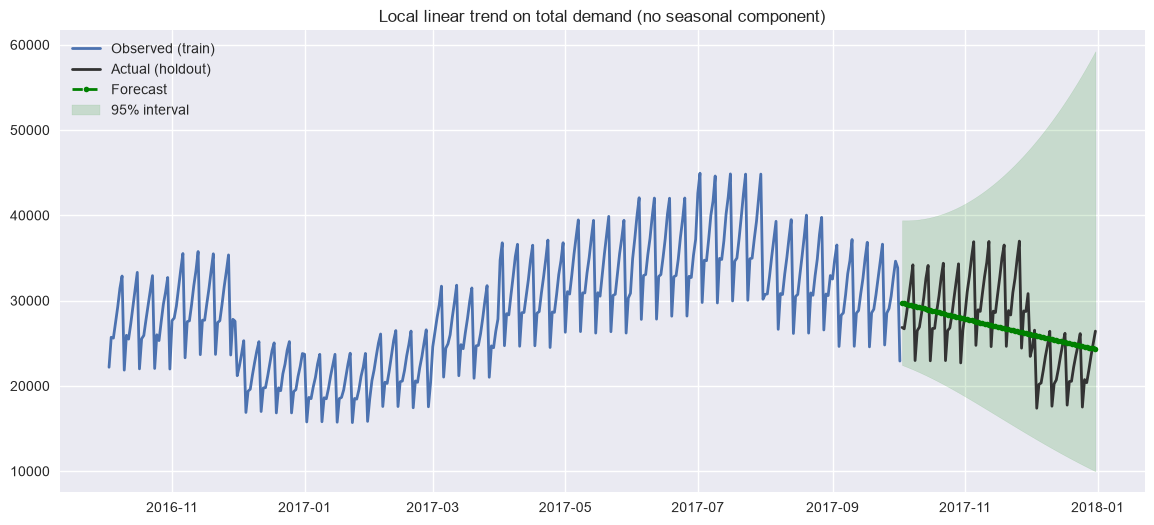

In [60]:
d_train, d_valid = train_valid_split(log_demand, horizon=HORIZON2)
valid_orig2 = demand.iloc[-HORIZON2:]                    # holdout on the original scale
recent = demand.iloc[-(365 + HORIZON2):-HORIZON2]        # last year of training data, keeps charts legible

llt2_res = sm.tsa.UnobservedComponents(d_train, level="local linear trend").fit(disp=False)

fc = llt2_res.get_forecast(HORIZON2)
llt2_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("Local linear trend:", forecast_metrics(valid_orig2, llt2_pred))
plot_forecast(recent, valid_orig2, llt2_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="Local linear trend on total demand (no seasonal component)")

This code fits a local linear trend model to the logarithm of the retail sales data and evaluates its forecasting performance on a holdout period of 90 days.

It begins by splitting the log-transformed demand time series (`log_demand`) into training and validation sets using the `train_valid_split` function, with a horizon of `HORIZON2` (90 days). The original scale values for the validation set are stored in `valid_orig2`. A slice of the recent past data is also extracted to make the forecast plot more readable.

A local linear trend model is fitted to the training data (`d_train`) using `statsmodels.tsa.UnobservedComponents`. The `fit()` method estimates the model parameters, suppressing output during fitting.

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`HORIZON2`).  The predicted mean is exponentiated to convert it back to the original scale (sales units), and confidence intervals are calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`llt2_pred`) to the actual validation data on the original scale (`valid_orig2`). The resulting RMSE is printed to the console. 

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the recent past training data, the actual validation data, the forecasted values, and confidence intervals. The plot is titled "Local linear trend on total demand (no seasonal component)". This visualization allows for assessment of how well the local linear trend model captures the underlying trend in the sales data and makes accurate short-term predictions.

state vector size: 14
Structural (weekly + annual): {'MAE': 2921.96, 'RMSE': 3370.49}

estimated variances:
  sigma2.irregular                 0.00006413
  sigma2.level                     0.00000140
  sigma2.trend                     0.00000000
  sigma2.seasonal                  0.00000005
  sigma2.freq_seasonal_365.25(3)   0.00017219


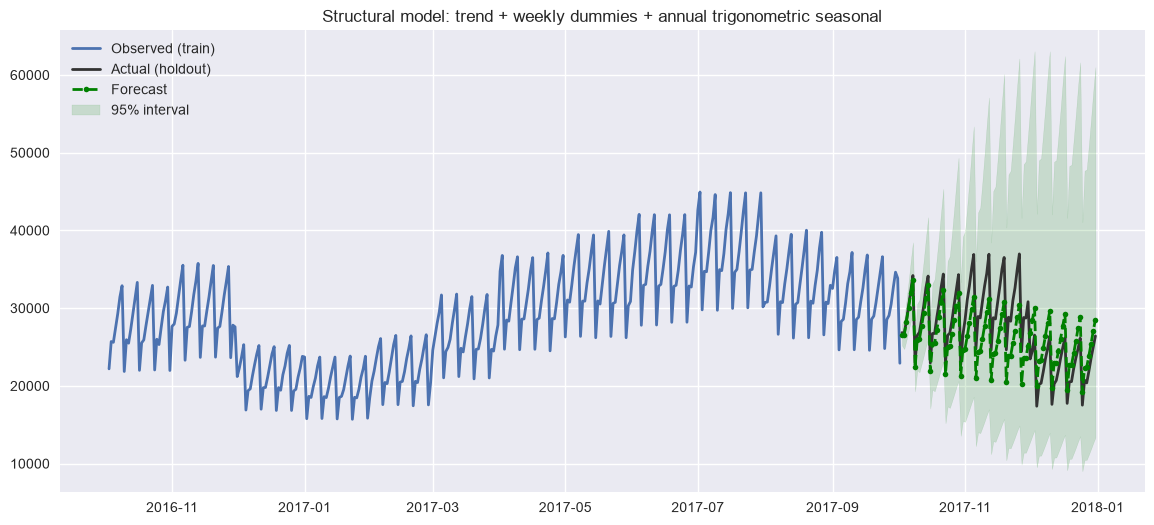

In [61]:
bsm2_res = sm.tsa.UnobservedComponents(
    d_train,
    level="local linear trend",
    seasonal=WEEKLY_PERIOD,                                      # day-of-week dummy seasonal
    freq_seasonal=[{"period": ANNUAL_PERIOD, "harmonics": 3}],   # annual cycle as 3 sine/cosine pairs
).fit(disp=False)

print(f"state vector size: {bsm2_res.model.k_states}")
fc = bsm2_res.get_forecast(HORIZON2)
bsm2_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("Structural (weekly + annual):", forecast_metrics(valid_orig2, bsm2_pred))
print("\nestimated variances:")
for name, val in zip(bsm2_res.param_names, bsm2_res.params):
    print(f"  {name:32s} {val:.8f}")

plot_forecast(recent, valid_orig2, bsm2_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="Structural model: trend + weekly dummies + annual trigonometric seasonal")

This code fits a more complex structural time series model to the logarithm of the retail sales data, incorporating both weekly and annual seasonality, and evaluates its forecasting performance.

It begins by fitting an unobserved components model using `statsmodels.tsa.UnobservedComponents` to the training data (`d_train`). This model includes:
- A local linear trend component (`level="local linear trend"`).
- Weekly seasonality represented by dummy variables with a period of `WEEKLY_PERIOD` (7 days).
- Annual seasonality modeled using trigonometric functions (sine and cosine pairs) with a period of `ANNUAL_PERIOD` (365.25 days) and 3 harmonics.

The model is fitted using the `fit()` method, suppressing output during fitting. The size of the state vector is printed to provide insight into the complexity of the model.

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`HORIZON2`).  The predicted mean is exponentiated to convert it back to the original scale (sales units), and confidence intervals are calculated by exponentiating the lower and upper bounds from `fc.conf_int()`.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`bsm2_pred`) to the actual validation data on the original scale (`valid_orig2`). The resulting RMSE is printed to the console. 

It also prints a list of estimated variances from the fitted model by iterating through the parameter names and values, formatted for readability. This provides insight into the relative importance of different components in the model.

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the recent past training data, actual validation data, forecasted values, and confidence intervals. The plot is titled "Structural model: trend + weekly dummies + annual trigonometric seasonal". This visualization allows for assessment of how well the structural model captures both the trend and seasonal patterns in the sales data and provides a comparison to the simpler local linear trend model.

SARIMAX + annual Fourier: {'MAE': 1769.42, 'RMSE': 2522.76}


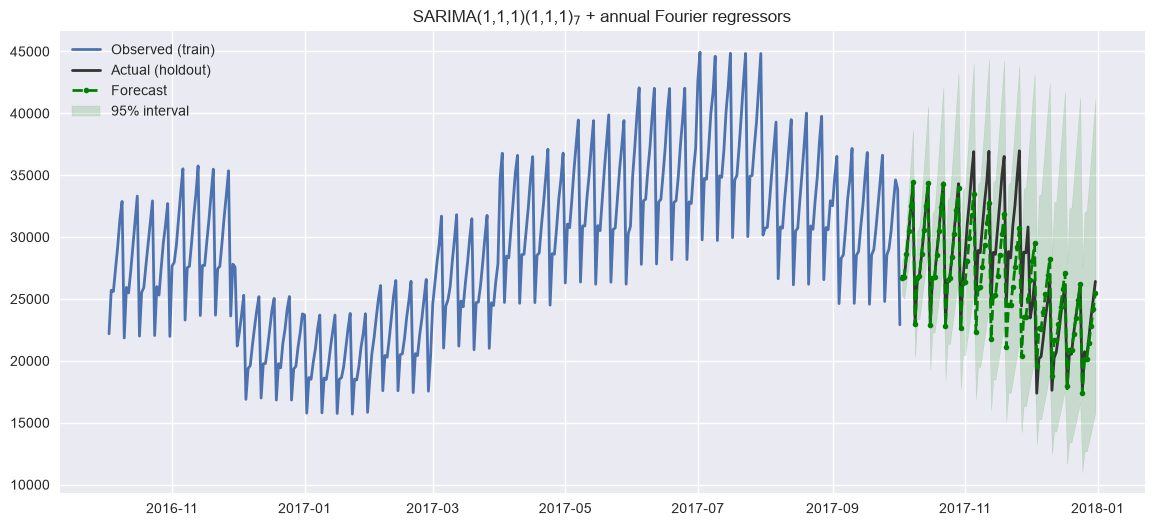

In [62]:
from statsmodels.tsa.deterministic import Fourier    # first appearance in this notebook, hence the local import

fourier = Fourier(period=ANNUAL_PERIOD, order=3)
X_train = fourier.in_sample(d_train.index)            # 6 columns: sin/cos pairs for 3 harmonics
X_future = fourier.out_of_sample(HORIZON2, index=d_train.index)

sarimax2_res = sm.tsa.SARIMAX(d_train, exog=X_train,
                              order=(1, 1, 1),
                              seasonal_order=(1, 1, 1, WEEKLY_PERIOD)).fit(disp=False)

fc = sarimax2_res.get_forecast(HORIZON2, exog=X_future)
sarimax2_pred = np.exp(fc.predicted_mean)
ci = np.exp(fc.conf_int())

print("SARIMAX + annual Fourier:", forecast_metrics(valid_orig2, sarimax2_pred))
plot_forecast(recent, valid_orig2, sarimax2_pred,
              lower=ci.iloc[:, 0], upper=ci.iloc[:, 1],
              title="SARIMA(1,1,1)(1,1,1)$_7$ + annual Fourier regressors")

This code fits a SARIMAX model with external regressors representing the annual seasonal component using Fourier terms to the logarithm of the retail sales data and evaluates its forecasting performance.

It first imports the `Fourier` class from `statsmodels.tsa.deterministic`. This class is used to generate trigonometric functions (sine and cosine pairs) that represent periodic patterns in the time series.

A `Fourier` object is created with a period equal to `ANNUAL_PERIOD` (365.25 days) and an order of 3, indicating three harmonics will be used to model the annual seasonality. The `in_sample()` method generates the Fourier terms for the training data (`d_train`), creating six columns representing sine and cosine pairs for each harmonic. Similarly, `out_of_sample()` generates the Fourier terms for the forecast horizon (`HORIZON2`).

A SARIMAX model is then fitted to the training data using `sm.tsa.SARIMAX`. The model includes an autoregressive (AR) order of 1, a differencing order of 1, and a moving average (MA) order of 1. It also incorporates seasonal components with a seasonal AR order of 1, a seasonal differencing order of 1, a seasonal MA order of 1, and a weekly period (`WEEKLY_PERIOD`). The Fourier terms generated earlier are included as external regressors (`exog=X_train`).

Next, forecasts are generated for the validation period using the `get_forecast()` method, specifying the forecast horizon (`HORIZON2`) and providing the corresponding future Fourier terms as external regressors (`exog=X_future`). The predicted mean is exponentiated to convert it back to the original scale (sales units), and confidence intervals are calculated.

The forecasting performance of this model is then evaluated using the `forecast_metrics` function, comparing the forecasts (`sarimax2_pred`) to the actual validation data on the original scale (`valid_orig2`). The resulting RMSE is printed to the console. 

Finally, a forecast plot is generated using the `plot_forecast` function, displaying the recent past training data, actual validation data, forecasted values, and confidence intervals. The plot is titled "SARIMA(1,1,1)(1,1,1)$_7$ + annual Fourier regressors". This visualization allows for assessment of how well the SARIMAX model with Fourier terms captures both the trend and seasonal patterns in the sales data.

In [63]:
ets2_res = ETSModel(d_train, error="add", trend="add", seasonal="add",
                    seasonal_periods=WEEKLY_PERIOD).fit(disp=False)

print("smoothing parameters:")
for name, val in zip(ets2_res.param_names, ets2_res.params):
    if "smoothing" in name:
        print(f"  {name:22s} {val:.4f}")

ets2_pred = np.exp(ets2_res.forecast(HORIZON2))
print("\nETS(A,A,A), weekly seasonality only:", forecast_metrics(valid_orig2, ets2_pred))

smoothing parameters:
  smoothing_level        0.9999
  smoothing_trend        0.0001
  smoothing_seasonal     0.0000

ETS(A,A,A), weekly seasonality only: {'MAE': 3273.55, 'RMSE': 4654.85}


This code fits an Exponential Smoothing State Space (ETS) model with weekly seasonality to the logarithm of the retail sales data and evaluates its forecasting performance.

It begins by fitting an ETS model using `statsmodels.tsa.exponential_smoothing.ets.ETSModel` to the training data (`d_train`). The model is specified with additive error, additive trend, and additive seasonal components (error="add", trend="add", seasonal="add").  The seasonal period is set to `WEEKLY_PERIOD` (7 days), representing weekly seasonality. The model is fitted using the `fit()` method, suppressing output during fitting.

Next, it prints the estimated smoothing parameters of the ETS model. These parameters control how much weight is given to recent observations versus past estimates when updating the level, trend, and seasonal components. It iterates through the parameter names (`ets2_res.param_names`) and values (`ets2_res.params`), printing only those parameters that contain "smoothing" in their name, formatted for readability.

Forecasts are then generated for the validation period using the `forecast()` method of the fitted ETS model, specifying the forecast horizon (`HORIZON2`). The forecasted values are exponentiated to convert them back to the original scale (sales units). 

Finally, the forecasting performance of the ETS model is evaluated using the `forecast_metrics` function, comparing the forecasts (`ets2_pred`) to the actual validation data on the original scale (`valid_orig2`). The resulting RMSE is printed to the console. This provides a measure of how well the ETS model captures the underlying patterns in the sales data and makes accurate predictions, focusing specifically on weekly seasonality.

In [64]:
scores2 = {
    "LocalLinearTrend (no seasonal)": forecast_metrics(valid_orig2, llt2_pred)["RMSE"],
    "Structural (weekly + annual)": forecast_metrics(valid_orig2, bsm2_pred)["RMSE"],
    "SARIMAX + annual Fourier": forecast_metrics(valid_orig2, sarimax2_pred)["RMSE"],
    "ETS(A,A,A) weekly": forecast_metrics(valid_orig2, ets2_pred)["RMSE"],
}
compare_models(scores2, baseline="LocalLinearTrend (no seasonal)")

,RMSE,delta_vs_baseline,improved
model,,,
SARIMAX + annual Fourier,2522.76,-1896.03,True
Structural (weekly + annual),3370.49,-1048.30,True
LocalLinearTrend (no seasonal),4418.79,0.00,False
"ETS(A,A,A) weekly",4654.85,236.06,False


This code summarizes and compares the forecasting performance of several different time series models on the retail sales data.

It first creates a dictionary called `scores2` where keys are model names and values are their corresponding Root Mean Squared Error (RMSE) scores calculated using the `forecast_metrics` function. The models included in the comparison are: Local Linear Trend, Structural Model with weekly and annual seasonality, SARIMAX with Fourier terms for annual seasonality, and ETS(A,A,A) with only weekly seasonality.

Then, it calls the `compare_models` function with the `scores2` dictionary and specifies the "LocalLinearTrend (no seasonal)" model as the baseline. The `compare_models` function generates a Pandas DataFrame that displays each model’s RMSE, its difference from the baseline RMSE, and a boolean flag indicating whether the model performed better than the baseline. The DataFrame is sorted by RMSE in ascending order, making it easy to identify the best-performing models relative to the baseline. This provides a concise and informative comparison of the forecasting accuracy of different time series modeling techniques for this specific dataset.

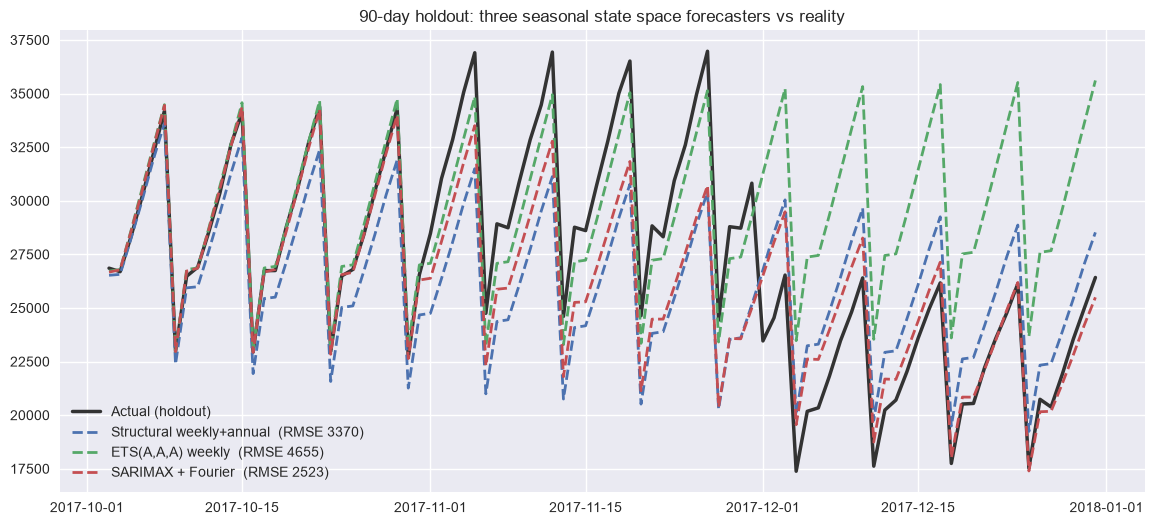

In [65]:
fig, ax = plt.subplots()
ax.plot(valid_orig2.index, valid_orig2.values, lw=2.5, color="#333333", label="Actual (holdout)")
ax.plot(valid_orig2.index, bsm2_pred.values, lw=2, linestyle="--",
        label=f"Structural weekly+annual  (RMSE {scores2['Structural (weekly + annual)']:.0f})")
ax.plot(valid_orig2.index, ets2_pred.values, lw=2, linestyle="--",
        label=f"ETS(A,A,A) weekly  (RMSE {scores2['ETS(A,A,A) weekly']:.0f})")
ax.plot(valid_orig2.index, sarimax2_pred.values, lw=2, linestyle="--",
        label=f"SARIMAX + Fourier  (RMSE {scores2['SARIMAX + annual Fourier']:.0f})")
ax.set_title("90-day holdout: three seasonal state space forecasters vs reality")
ax.set_xlabel(""); plt.legend(); plt.show()

This code generates a plot comparing the forecasts from three different time series models (Structural, ETS(A,A,A), and SARIMAX with Fourier terms) to the actual values in the validation set of the retail sales data.

It creates a Matplotlib figure and axes object. The actual validation data (`valid_orig2`) is plotted as a thick gray line, labeled "Actual (holdout)". 

The forecasts from each model are then plotted on the same graph:
- Structural Model’s forecast (`bsm2_pred`) is plotted as a dashed line with its RMSE score included in the label.
- ETS(A,A,A) weekly model’s forecast (`ets2_pred`) is plotted as a dashed line with its RMSE score included in the label.
- SARIMAX + Fourier model’s forecast (`sarimax2_pred`) is plotted as a dashed line with its RMSE score included in the label.

The plot is titled "90-day holdout: three seasonal state space forecasters vs reality", the x-axis label is removed, and a legend is displayed to identify each model’s forecast. This visualization allows for a direct comparison of the forecasting performance of the different models on the validation data, providing insights into their strengths and weaknesses in capturing both weekly and annual seasonality. The inclusion of RMSE scores in the labels further facilitates this comparison.